# Part I — Data Analytics: Answers

**Assignment:** Global Events, Commodities and Currency Markets
**Datasets:** brentOil.csv · gold100years.csv · silver100years.csv · swift_currency_tracker_all_reports.csv · USDG.csv

---

## A. Data Preparation and Understanding

---


In [1]:
#from google.colab import drive, files
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#import matplotlib.pyplot as
import numpy as np
#uploaded = files.upload()

**Q1 — What are the start and end dates of each dataset?**
| Dataset | Start | End | Coverage |
|---|---|---|---|
| Brent Oil | 1 January 1946 | 1 March 2026 | ~80 years, monthly |
| Gold | 1 January 1915 | 1 April 2026 | ~111 years, monthly |
| Silver | 1 January 1915 | 1 April 2026 | ~111 years, monthly |
| SWIFT | 1 January 2026 | 1 April 2026 | 4 report months |
| USDG | 29 April 2025 | 28 April 2026 | 366 days, daily |

---

In [2]:
# Q1 — What are the start and end dates of each dataset?
import pandas as pd

# If files were uploaded via files.upload() in Google Colab,
# they are stored in /content/ — just use the filename directly.
brent  = pd.read_csv("../01_Raw_Data/brentOil.csv")
gold   = pd.read_csv("../01_Raw_Data/gold100years.csv")
silver = pd.read_csv("../01_Raw_Data/silver100years.csv")
for df in [brent, gold, silver]:
    df["Date"] = pd.to_datetime(df["Date"], format="%m/%d/%Y")
swift  = pd.read_csv("../01_Raw_Data/swift_currency_tracker_all_reports.csv")
usdg   = pd.read_csv("../01_Raw_Data/USDG.csv", parse_dates=["Date"])

def fmt(dt):
    return f"{dt.day} {dt.strftime('%B %Y')}"

for name, df in [("Brent", brent), ("Gold", gold), ("Silver", silver), ("USDG", usdg)]:
    print(f"{name}: {fmt(df.Date.min())} → {fmt(df.Date.max())}")

# SWIFT — monthly reports; parse to date so we can apply the same format
swift_months = pd.to_datetime(swift.report_month.unique(), format="%B %Y")
print(f"SWIFT: {fmt(swift_months.min())} → {fmt(swift_months.max())}")


Brent: 1 January 1946 → 1 March 2026
Gold: 1 January 1915 → 1 April 2026
Silver: 1 January 1915 → 1 April 2026
USDG: 29 April 2025 → 28 April 2026
SWIFT: 1 January 2026 → 1 April 2026


### Q2 — How many rows does each dataset have?

| Dataset | Rows | Columns |
|---|---|---|
| Brent Oil | 963 | 2 (Date, Value) |
| Gold | 1,336 | 2 (Date, Value) |
| Silver | 1,336 | 2 (Date, Value) |
| SWIFT | 330 | 10 (report_month,data_month,source_report_name,metric,category,currency_or_economy,value,unit,rmb_global_rank,notes)|
| USDG | 366 | 4 (Date, Price_USD, MarketCap_USD, Volume_USD) |

---


In [3]:
# Q2 — How many rows does each dataset have?
for name, df in [("Brent", brent), ("Gold", gold), ("Silver", silver), ("SWIFT", swift), ("USDG", usdg)]:
    print(f"{name}: {len(df):,} Rows, {df.shape[1]} Columns")


Brent: 963 Rows, 2 Columns
Gold: 1,336 Rows, 2 Columns
Silver: 1,336 Rows, 2 Columns
SWIFT: 330 Rows, 10 Columns
USDG: 366 Rows, 4 Columns


### Q3 — Are there any missing values or duplicate dates?

| Dataset | Missing Values | Duplicate Dates/Rows | Negative/Zero Prices |
|---|---|---|---|
| Brent Oil | 0 | 0 | 0 |
| Gold | 0 | 0 | 0 |
| Silver | 0 | 0 | 0 |
| USDG | 0 | **1** ⚠️ | 0 |
| SWIFT | **388** ⚠️ | 0 | — (no price column) |

**Conclusion and Cleaning Actions:**

- **USDG — 1 duplicate date:** One date appears twice. Fixed by keeping the first occurrence: `usdg = usdg.drop_duplicates(subset="Date", keep="first").reset_index(drop=True)`
- **SWIFT — 388 missing values:** SWIFT data is in long format; each metric uses only a subset of columns, leaving others as NaN. This is a structural characteristic of the dataset, not a data error — no action required.
- **Brent, Gold, Silver:** Fully clean, no action required.

---

In [4]:
# Q3 — Are there any missing values or duplicate dates?

# Brent, Gold, Silver — price column: Value
for name, df in [("Brent", brent), ("Gold", gold), ("Silver", silver)]:
    missing   = df.isna().sum().sum()
    dup_dates = df.Date.duplicated().sum()
    negatives = (df.Value <= 0).sum()
    print(f"{name}: missing={missing}, duplicate dates={dup_dates}, negative/zero={negatives}")

# USDG — price column: Price_USD (different schema)
usdg_missing   = usdg.isna().sum().sum()
usdg_dup_dates = usdg.Date.duplicated().sum()
usdg_negatives = (usdg.Price_USD <= 0).sum()
print(f"USDG: missing={usdg_missing}, duplicate dates={usdg_dup_dates}, negative/zero={usdg_negatives}")

# SWIFT — uses report_month (text) instead of a date column; check duplicate rows and missing values
swift_missing  = swift.isna().sum().sum()
swift_dup_rows = swift.duplicated().sum()
print(f"SWIFT: missing={swift_missing}, duplicate rows={swift_dup_rows}")


Brent: missing=0, duplicate dates=0, negative/zero=0
Gold: missing=0, duplicate dates=0, negative/zero=0
Silver: missing=0, duplicate dates=0, negative/zero=0
USDG: missing=0, duplicate dates=1, negative/zero=0
SWIFT: missing=388, duplicate rows=0


### Q4 — Format the date column; add Month and Year columns.

The Date column was originally in `MM/DD/YYYY` format (monthly data, day always = 1). It was parsed to datetime using `pd.to_datetime(df["Date"], format="%m/%d/%Y")` in pandas (see Q1). `Year`, `Month`, and `MonthName` columns were derived from the Date column for use in grouping and visualization.

**Cleaning note:**
> "Date columns arrived in MM/DD/YYYY format and were converted to pandas datetime using `format=\"%m/%d/%Y\"`. Month and Year columns were derived. No missing or erroneous rows were found."

---


In [5]:
# Q4 — Format the date column; add Month and Year columns.

# Brent, Gold, Silver — MM/DD/YYYY format, already parsed in Q1
for df in [brent, gold, silver]:
    df["Year"]      = df.Date.dt.year
    df["Month"]     = df.Date.dt.month
    df["MonthName"] = df.Date.dt.strftime("%b")  # Jan, Feb, ...

# USDG — standard YYYY-MM-DD format, same derivation
usdg["Year"]      = usdg.Date.dt.year
usdg["Month"]     = usdg.Date.dt.month
usdg["MonthName"] = usdg.Date.dt.strftime("%b")

print(brent[["Date","Year","Month","Value"]].head())
print(usdg[["Date","Year","Month","Price_USD"]].head())


        Date  Year  Month  Value
0 1946-01-01  1946      1  21.23
1 1946-02-01  1946      2  21.35
2 1946-03-01  1946      3  21.11
3 1946-04-01  1946      4  22.79
4 1946-05-01  1946      5  22.67
        Date  Year  Month  Price_USD
0 2025-04-29  2025      4   0.999519
1 2025-04-30  2025      4   1.000076
2 2025-05-01  2025      5   0.999766
3 2025-05-02  2025      5   0.999917
4 2025-05-03  2025      5   1.000550


### Q5 — List the metrics in the SWIFT dataset.

The `metric` column contains 8 distinct categories:

| Metric | Rows | Topic |
|---|---|---|
| Global Payment Share | 80 | Global payment share (%) |
| International Payment Share (ex-Eurozone) | 80 | Payment share excluding Eurozone |
| Offshore RMB by Economy | 60 | Offshore RMB share by country |
| Trade Finance Share | 40 | Trade finance share |
| FX Spot Currency Ranking | 40 | FX spot market ranking |
| FX Spot Economies (RMB) | 24 | RMB FX spot economies |
| RMB MoM Payment Growth | 4 | RMB month-on-month growth (%) |
| All Currencies MoM Payment Growth | 2 | All currencies MoM growth |

---


In [6]:
# Q5 — List the metrics in the SWIFT dataset.
print(swift.metric.unique())
print(swift.groupby("metric").size())


['Global Payment Share' 'International Payment Share (ex-Eurozone)'
 'RMB MoM Payment Growth' 'All Currencies MoM Payment Growth'
 'Offshore RMB by Economy' 'Trade Finance Share'
 'FX Spot Currency Ranking' 'FX Spot Economies (RMB)']
metric
All Currencies MoM Payment Growth             2
FX Spot Currency Ranking                     40
FX Spot Economies (RMB)                      24
Global Payment Share                         80
International Payment Share (ex-Eurozone)    80
Offshore RMB by Economy                      60
RMB MoM Payment Growth                        4
Trade Finance Share                          40
dtype: int64


---

## B. Descriptive Analytics

---

### Q6 — In which years did Brent Oil reach its highest and lowest prices?

| | Value (\$/barrel) | Year | Context |
|---|---|---|---|
| **Highest** | 211.21 | 2008 | Peak global energy demand |
| **Lowest** | 21.11 | 1946 | Start of records, post-war low demand |

---

In [7]:
# Q6 — In which years did Brent Oil reach its highest and lowest prices?
brent["Year"] = brent.Date.dt.year

idx_max = brent.Value.idxmax()
idx_min = brent.Value.idxmin()

print("MAX:", brent.loc[idx_max, "Value"], "—", brent.loc[idx_max, "Date"].year)
print("MIN:", brent.loc[idx_min, "Value"], "—", brent.loc[idx_min, "Date"].year)


MAX: 211.21 — 2008
MIN: 21.11 — 1946


### Q7 — In which years did Gold reach its highest and lowest prices?


| | Value (\$/oz) | Year | Context |
|---|---|---|---|
| **Highest** | 5,277.89 | 2026 | Iran-Hormuz crisis + BRICS gold accumulation — *Critical New Context*; *A New Financial Order II* |
| **Lowest** | 19.25 | 1915 | Gold standard era, pre-WWI — World Gold Council / IMF |

---

In [8]:
# Q7 — In which years did Gold reach its highest and lowest prices?
gold["Year"] = gold.Date.dt.year

idx_max = gold.Value.idxmax()
idx_min = gold.Value.idxmin()

print("MAX:", gold.loc[idx_max, "Value"], "—", gold.loc[idx_max, "Date"].year)
print("MIN:", gold.loc[idx_min, "Value"], "—", gold.loc[idx_min, "Date"].year)


MAX: 5277.89 — 2026
MIN: 19.25 — 1915


### Q8 — In which years did Silver reach its highest and lowest prices?


| | Value (\$/oz) | Year | Context |
|---|---|---|---|
| **Highest** | 113.95 | 2026 | Industrial demand spike + safe-haven effect — Silver Institute |
| **Lowest** | 0.28 | 1932 | Great Depression trough — World Bank |

---

In [9]:
# Q8 — In which years did Silver reach its highest and lowest prices?
silver["Year"] = silver.Date.dt.year

idx_max = silver.Value.idxmax()
idx_min = silver.Value.idxmin()

print("MAX:", silver.loc[idx_max, "Value"], "—", silver.loc[idx_max, "Date"].year)
print("MIN:", silver.loc[idx_min, "Value"], "—", silver.loc[idx_min, "Date"].year)


MAX: 113.9528 — 2026
MIN: 0.28 — 1932


### Q9 — Calculate annual average prices (Brent, Gold, Silver).

Last 10 years summary:

| Year | Brent (\$/bbl) | Gold (\$/oz) | Silver (\$/oz) |
|---|---|---|---|
| 2017 | 69.85 | 1,269.34 | 17.24 |
| 2018 | 84.91 | 1,265.60 | 15.64 |
| 2019 | 74.03 | 1,405.32 | 16.36 |
| 2020 | 49.19 | 1,784.66 | 20.80 |
| 2021 | 83.02 | 1,792.73 | 24.97 |
| 2022 | 106.45 | 1,798.96 | 21.67 |
| 2023 | 84.19 | 1,953.69 | 23.58 |
| 2024 | 79.83 | 2,404.58 | 28.13 |
| 2025 | 65.93 | 3,472.54 | 41.50 |
| 2026 | 78.67 | 4,881.62 | 96.08 |

> **Note:** 2026 annual average is based on the months available so far — January–March for Brent (3 months), January–April for Gold and Silver (4 months) — not just January.

---



In [10]:
# Q9 — Calculate annual average prices (Brent, Gold, Silver).
brent_yr  = brent.groupby("Year").Value.mean().rename("Brent_avg")
gold_yr   = gold.groupby("Year").Value.mean().rename("Gold_avg")
silver_yr = silver.groupby("Year").Value.mean().rename("Silver_avg")

annual = pd.concat([brent_yr, gold_yr, silver_yr], axis=1).round(2)

# Keep only years where all three datasets overlap (Brent starts 1946, Gold/Silver from 1915)
annual_common = annual.dropna()
print(annual_common.tail(10))  # last 10 common years (2016–2025)

annual_common.to_csv("../02_Cleaned_Data/annual_averages.csv")  # export for Excel

# Google Colab: download CSV to local machine
# from google.colab import files
# # files.download("../02_Cleaned_Data/annual_averages.csv")


      Brent_avg  Gold_avg  Silver_avg
Year                                 
2017      69.85   1269.34       17.24
2018      84.91   1265.60       15.64
2019      74.03   1405.32       16.36
2020      49.19   1784.66       20.80
2021      83.02   1792.73       24.97
2022     106.45   1798.96       21.67
2023      84.19   1953.69       23.58
2024      79.83   2404.58       28.13
2025      65.93   3472.54       41.50
2026      78.67   4881.62       96.08


### Q10 — Which 5 years had the highest annual average Brent price?

| Rank | Year | Annual Average (\$/bbl) |
|---|---|---|
| 1 | 2008 | \$150.96 |
| 2 | 1980 | \$149.86 |
| 3 | 2011 | \$142.12 |
| 4 | 2013 | \$138.30 |
| 5 | 2012 | \$135.27 |

---

In [11]:
# Q10 — Which 5 years had the highest annual average Brent price?
top5_brent = brent.groupby("Year").Value.mean().nlargest(5)
print(top5_brent)


Year
2008    150.963333
1980    149.860000
2011    142.115000
2013    138.301667
2012    135.268333
Name: Value, dtype: float64


### Q11 — Which 5 years had the highest annual average Gold price?

| Rank | Year | Annual Average (\$/oz) |
|---|---|---|
| 1 | 2026 | \$4,881.62 |
| 2 | 2025 | \$3,472.54 |
| 3 | 2024 | \$2,404.58 |
| 4 | 2023 | \$1,953.69 |
| 5 | 2022 | \$1,798.96 |

> The last 5 years represent a full Gold bull run — every year since 2022 has broken the previous year's record.

In [12]:
# Q11 — Which 5 years had the highest annual average Gold price?
top5_gold = gold.groupby("Year").Value.mean().nlargest(5)
print(top5_gold)


Year
2026    4881.619800
2025    3472.540975
2024    2404.577567
2023    1953.688517
2022    1798.956575
Name: Value, dtype: float64


### Q12 — Which 5 years had the highest annual average Silver price?

| Rank | Year | Annual Average (\$/oz) |
|---|---|---|
| 1 | 2026 | \$96.08 |
| 2 | 2025 | \$41.50 |
| 3 | 2011 | \$35.56 |
| 4 | 2012 | \$31.63 |
| 5 | 2024 | \$28.13 |

---

In [13]:
# Q12 — Which 5 years had the highest annual average Silver price?
top5_silver = silver.groupby("Year").Value.mean().nlargest(5)
print(top5_silver)


Year
2026    96.083200
2025    41.501500
2011    35.556667
2012    31.626667
2024    28.128033
Name: Value, dtype: float64


## C. Trend and Visual Analytics

---

### Q13 — Create a time series line chart for Brent Oil.

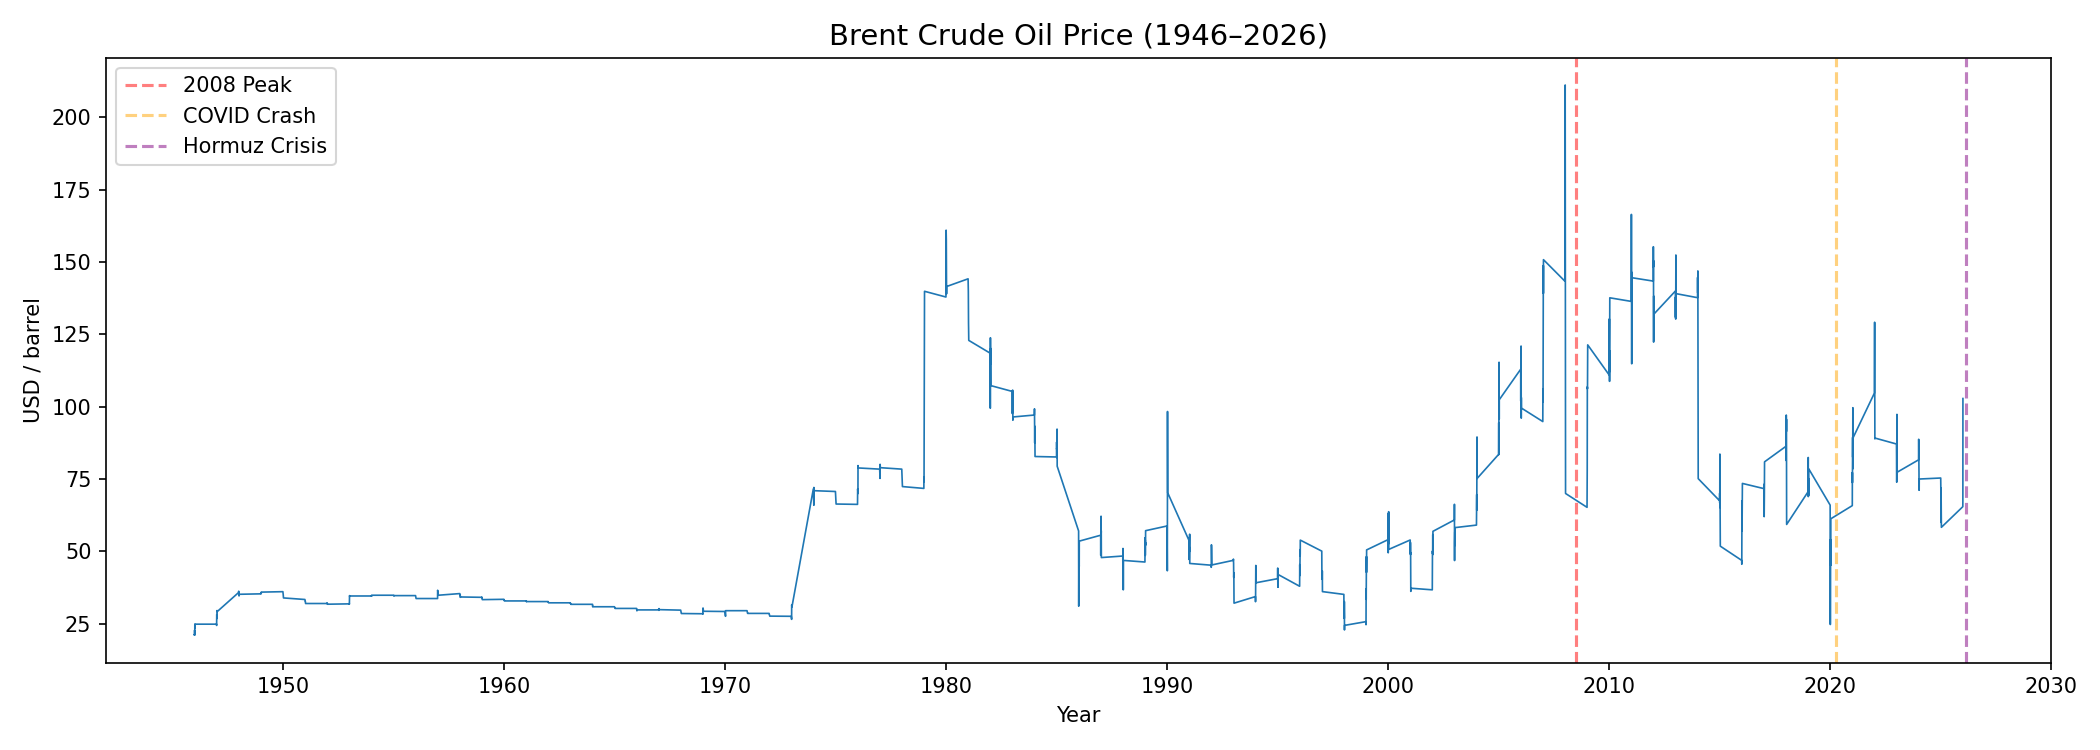

> Brent Crude Oil remained below \$20 from 1946 to 1973. The first major shock came with the 1973 OPEC embargo and the 1979 Iranian Revolution. Prices peaked at \$211 in 2008 driven by global energy demand, then crashed sharply during the financial crisis. The COVID-19 pandemic in 2020 caused futures contracts to go negative, the sharpest collapse in Brent history. The 2022 Ukraine war and the 2026 Iran-Hormuz crisis pushed Brent back toward $126, confirming that crude oil remains highly sensitive to geopolitical shocks.
>
> **Commentary sources:** Price values → brentOil.csv. 1973 OPEC embargo, 1979 Iranian Revolution, 2008 crisis → EIA (eia.gov). COVID-19 2020 impact → IEA (iea.org). 2022 Ukraine war → widely reported (Reuters, EIA). 2026 Iran-Hormuz crisis → *Critical New Context*.

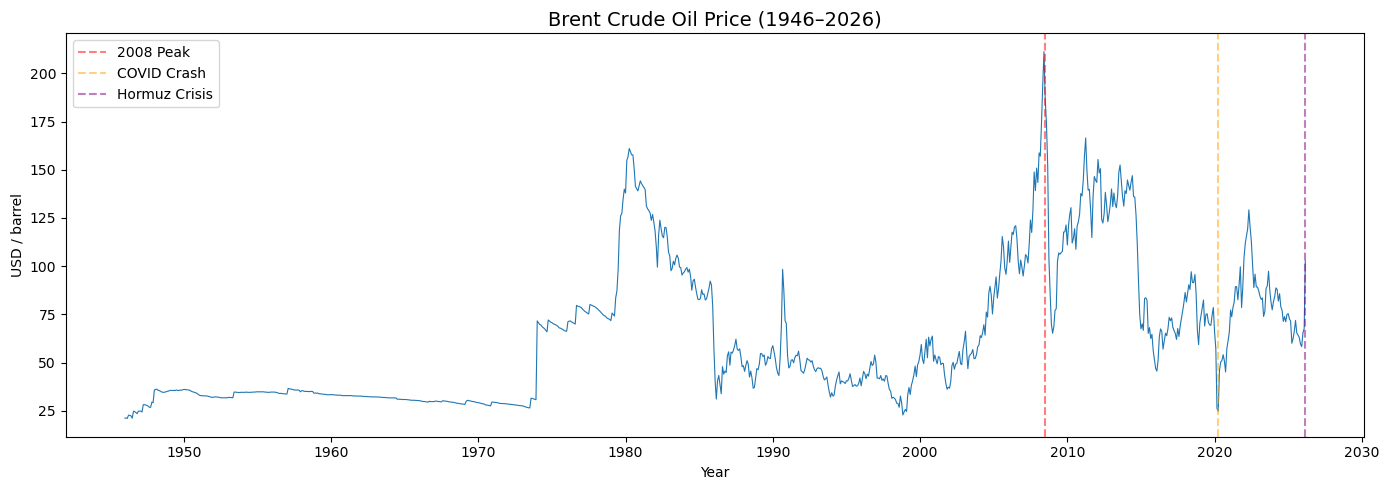

In [14]:
# Q13 — Create a time series line chart for Brent Oil.
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(brent.Date, brent.Value, linewidth=0.8, color="#1f77b4")
ax.set_title("Brent Crude Oil Price (1946–2026)", fontsize=14)
ax.set_xlabel("Year")
ax.set_ylabel("USD / barrel")

# Optional: annotate key geopolitical events
ax.axvline(pd.Timestamp("2008-07-01"), color="red", linestyle="--", alpha=0.5, label="2008 Peak")
ax.axvline(pd.Timestamp("2020-04-01"), color="orange", linestyle="--", alpha=0.5, label="COVID Crash")
ax.axvline(pd.Timestamp("2026-03-01"), color="purple", linestyle="--", alpha=0.5, label="Hormuz Crisis")
ax.legend()
plt.tight_layout()
plt.savefig("../04_Outputs/brent_line.png", dpi=150)
plt.show()

# Google Colab: download chart to local machine
# from google.colab import files
# # files.download("../04_Outputs/brent_line.png")


### Q14 — Create a time series line chart for Gold.

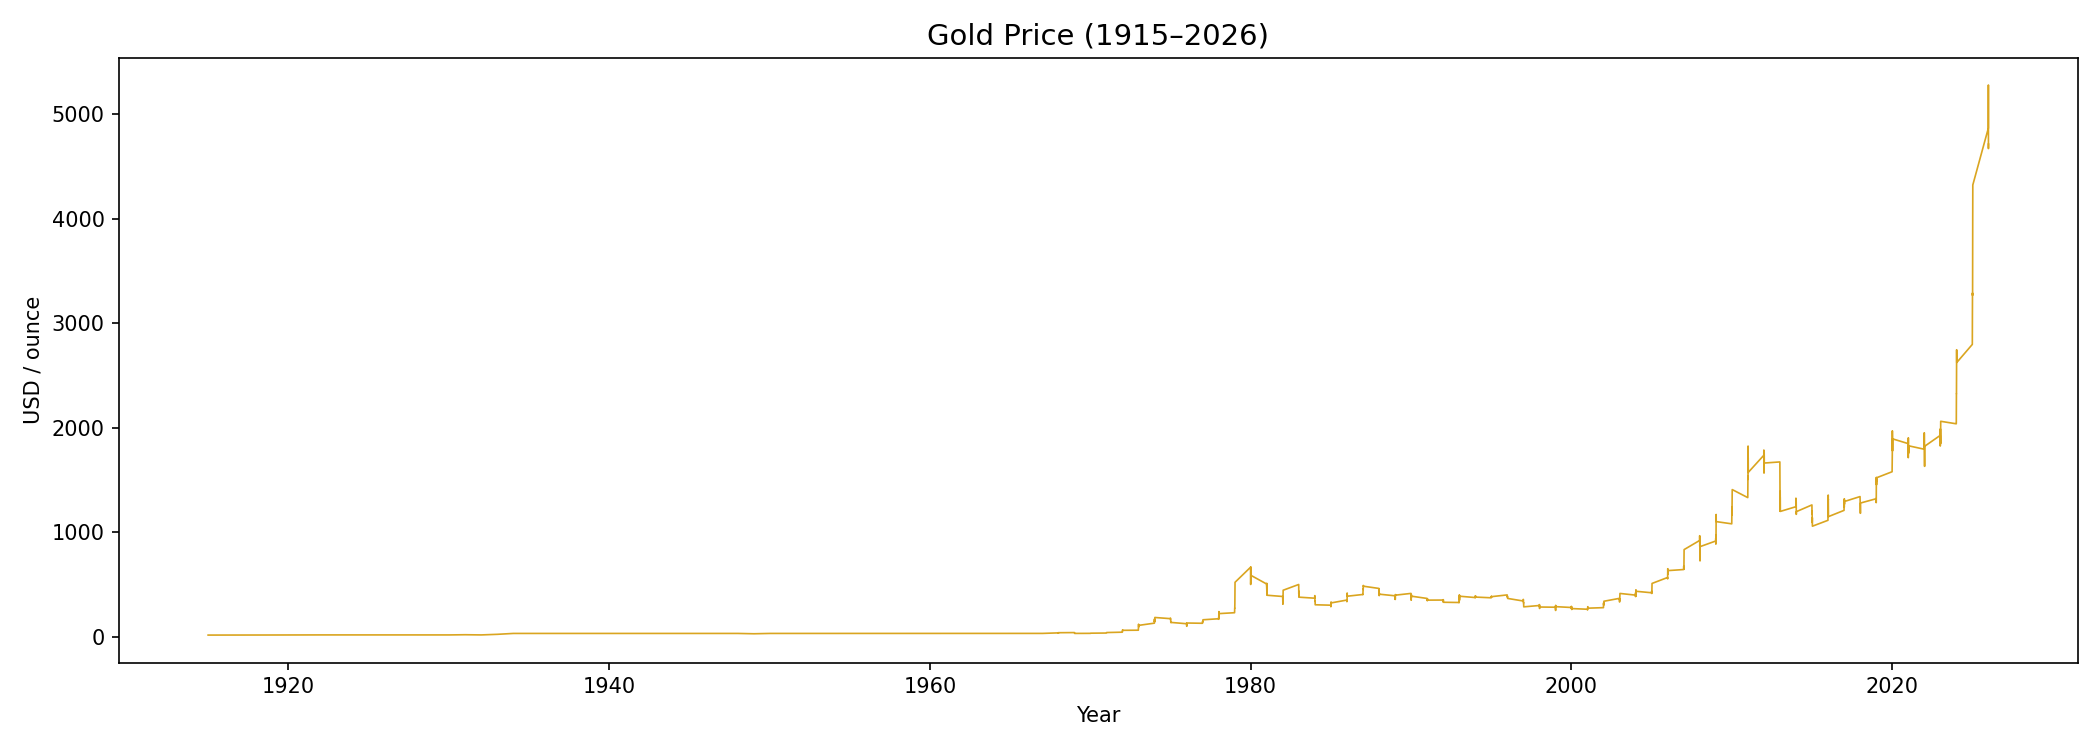

> Gold traded at a fixed price under the Bretton Woods system from 1915 to 1971 (\$35/oz), visible as a flat line on the chart. The 1971 Nixon Shock ended the gold standard and allowed free-floating prices. Post-2008 quantitative easing by central banks elevated gold's safe-haven status. The 2020–2022 pandemic and Ukraine war pushed prices past the \$2,000 mark, while the 2025–2026 Iran crisis and BRICS gold accumulation drove prices above \$5,000. The long-term trend is clearly upward, with acceleration during geopolitical and financial crises.
>
> **Commentary sources:** Price values → gold100years.csv. Bretton Woods & Nixon Shock → IMF (imf.org). QE policy & BRICS accumulation → World Gold Council (gold.org). 2025–2026 Iran crisis and BRICS gold accumulation → *A New Financial Order II*.

---

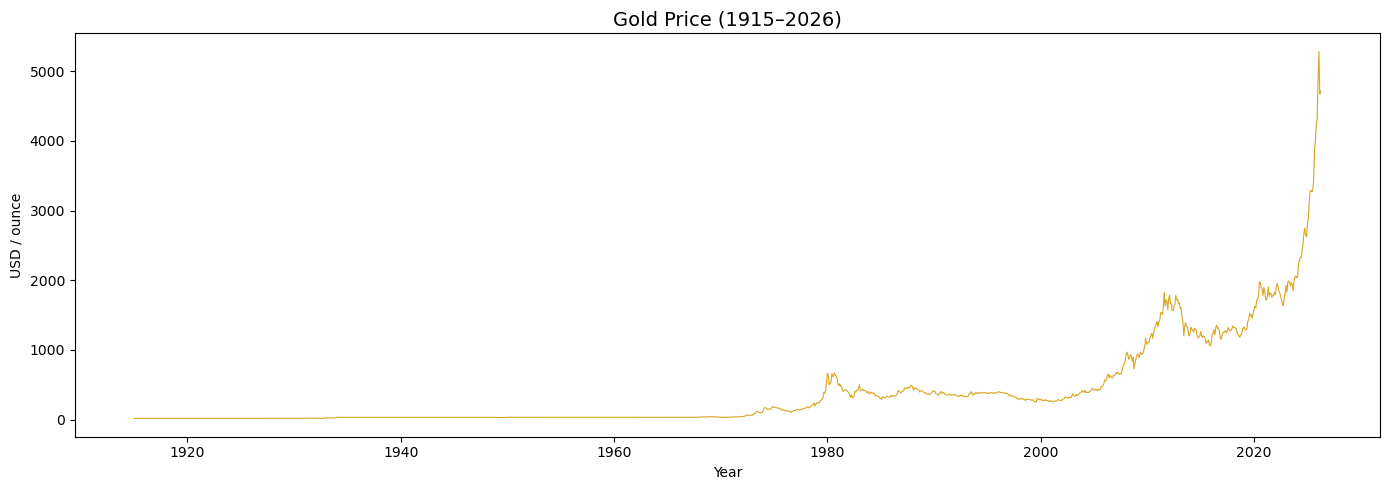

In [15]:
# Q14 — Create a time series line chart for Gold.
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(gold.Date, gold.Value, linewidth=0.8, color="goldenrod")
ax.set_title("Gold Price (1915–2026)", fontsize=14)
ax.set_xlabel("Year")
ax.set_ylabel("USD / ounce")

# Log scale is optional but recommended — 100+ year growth is more readable
# ax.set_yscale("log")

plt.tight_layout()
plt.savefig("../04_Outputs/gold_line.png", dpi=150)
plt.show()

# Google Colab: download chart to local machine
# from google.colab import files
# files.download("../04_Outputs/gold_line.png")


### Q15 — Create a time series line chart for Silver.

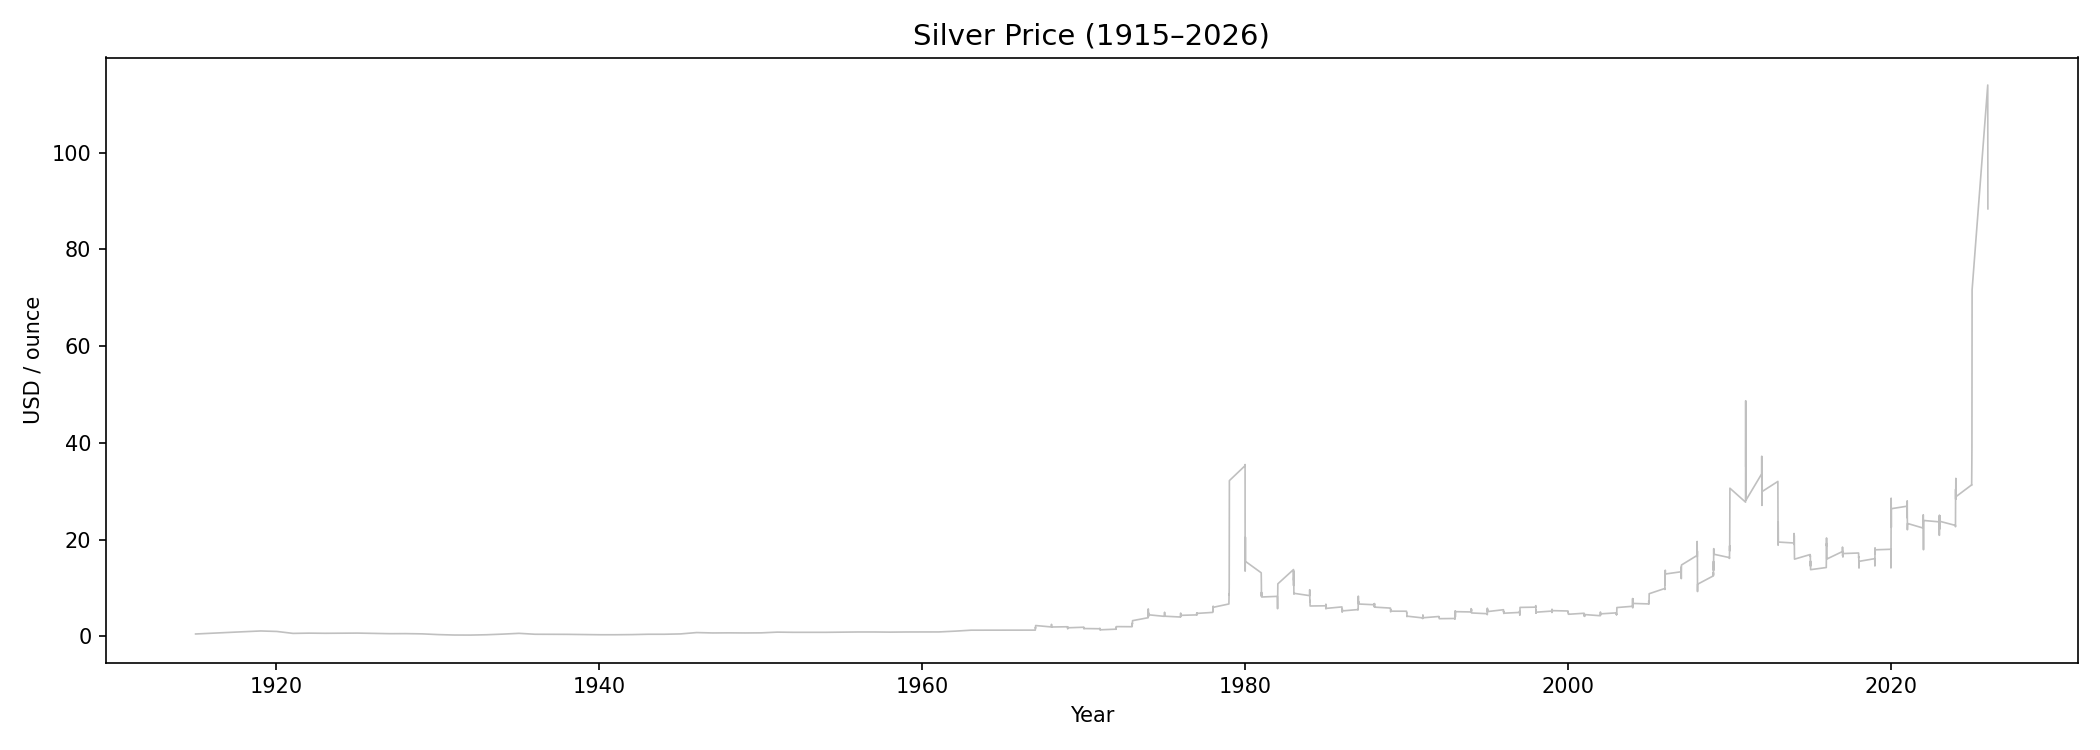

> The 1980 Hunt Brothers corner attempt pushed Silver past $50, a level challenged again in 2011 (\$49). In 2026, a combination of industrial demand (solar panels, EV batteries) and safe-haven buying drove prices to an all-time high of $113.95. Silver exhibits higher volatility than Gold due to its dual role as both a precious and industrial metal.
>
> **Commentary sources:** Price values → silver100years.csv. 1980 Hunt Brothers event → Silver Institute (silverinstitute.org). 2026 industrial demand context → Silver Institute (silverinstitute.org).

---

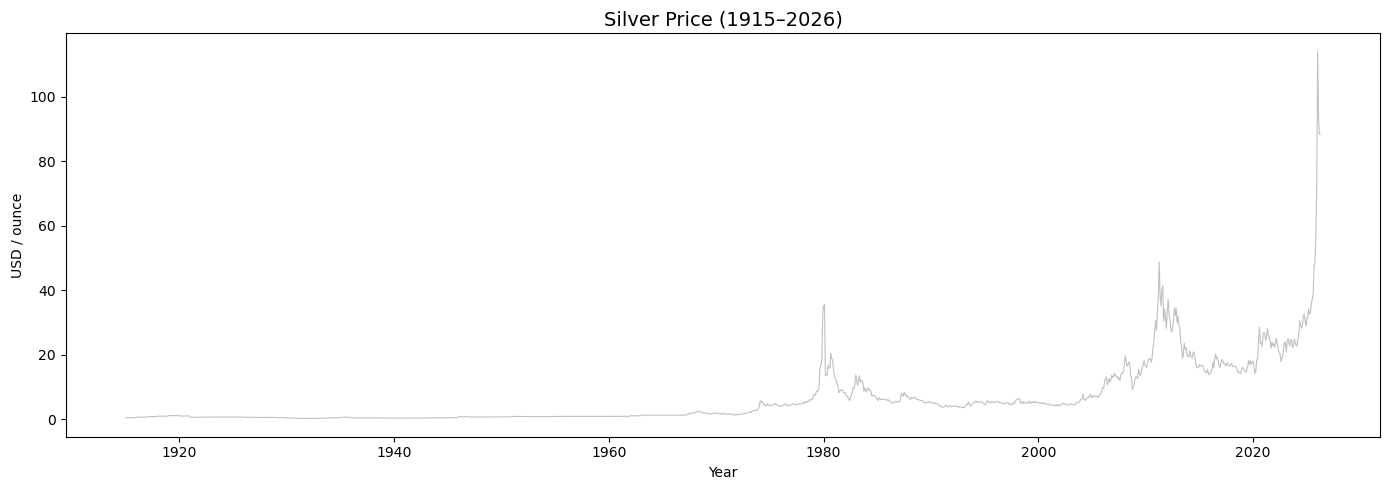

In [16]:
# Q15 — Create a time series line chart for Silver.
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(silver.Date, silver.Value, linewidth=0.8, color="silver")
ax.set_title("Silver Price (1915–2026)", fontsize=14)
ax.set_xlabel("Year")
ax.set_ylabel("USD / ounce")
plt.tight_layout()
plt.savefig("../04_Outputs/silver_line.png", dpi=150)
plt.show()

# Google Colab: download chart to local machine
# from google.colab import files
# files.download("../04_Outputs/silver_line.png")


### Q16 — Create a combined chart showing Gold and Silver.

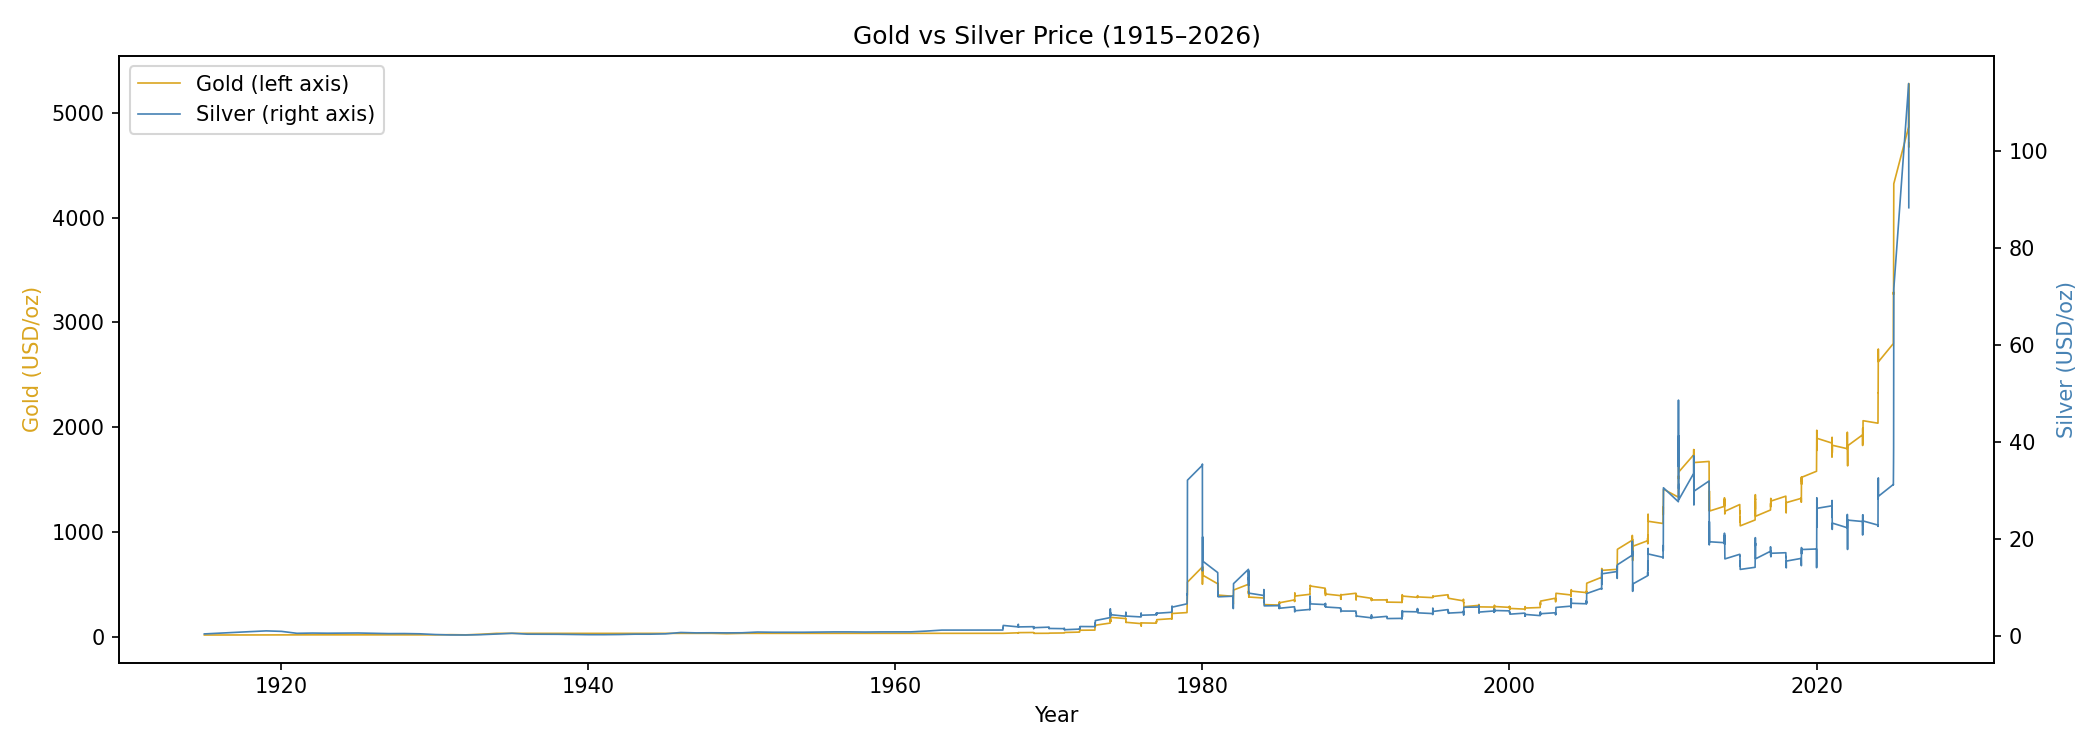

> Gold and Silver show high long-term correlation (~0.95). Both rise together during crises (safe-haven demand). However, Silver has significantly higher volatility (monthly std: Silver 7.7%, Gold 4.3%). In the 2011 peak and again in 2026, Silver outperformed Gold proportionally — evidence of its dual nature as both a safe-haven asset and an industrial commodity.
>
> **Commentary sources:** Correlation (~0.95) and volatility values → computed from gold100years.csv + silver100years.csv. 2011 and 2026 peak context → Silver Institute (silverinstitute.org).

---

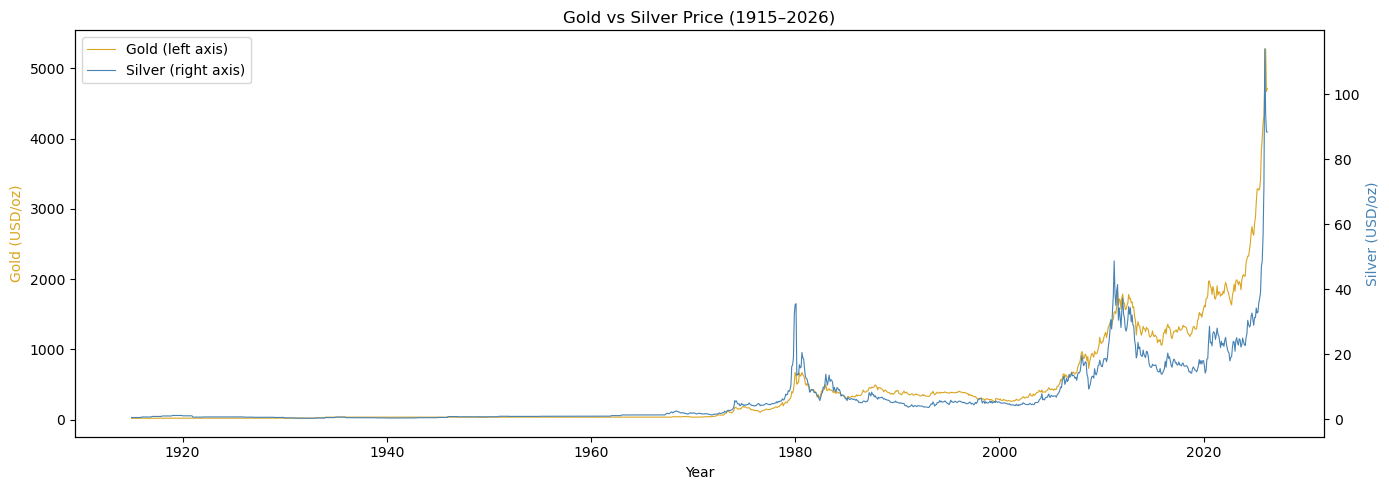

In [17]:
# Q16 — Create a combined chart showing Gold and Silver.
fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.plot(gold.Date, gold.Value, color="goldenrod", label="Gold (left axis)", linewidth=0.8)
ax1.set_ylabel("Gold (USD/oz)", color="goldenrod")

ax2 = ax1.twinx()
ax2.plot(silver.Date, silver.Value, color="steelblue", label="Silver (right axis)", linewidth=0.8)
ax2.set_ylabel("Silver (USD/oz)", color="steelblue")

ax1.set_title("Gold vs Silver Price (1915–2026)")
ax1.set_xlabel("Year")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.savefig("../04_Outputs/gold_silver_combined.png", dpi=150)
plt.show()

# Google Colab: download chart to local machine
# from google.colab import files
# files.download("../04_Outputs/gold_silver_combined.png")


### Q17 — Create a bar chart of annual average Brent prices for the last 10 years.

*(See: brent_bar_10yr.png)*
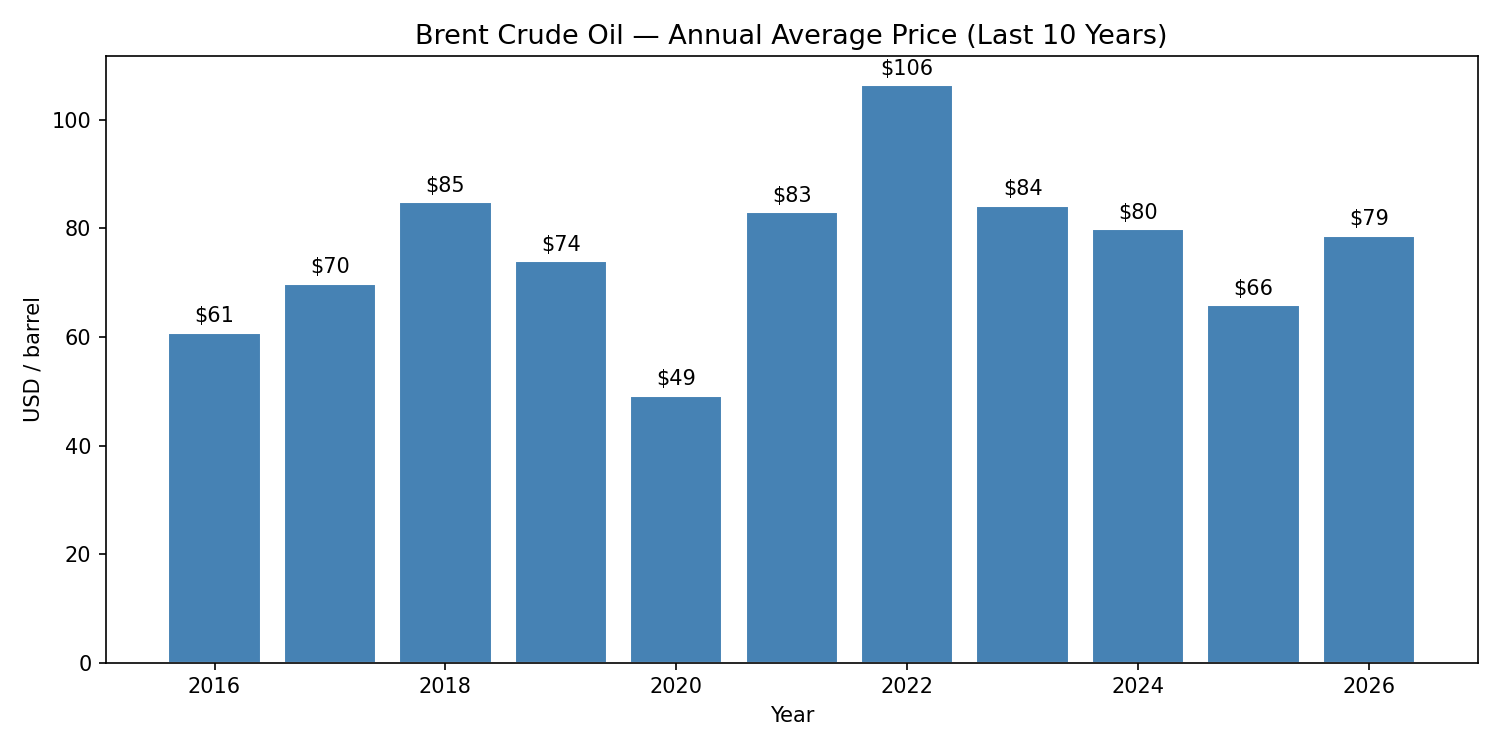

> Outside of the 2020 COVID dip, Brent stayed within the \$50–$100 range. The 2022 Ukraine war produced the decade's highest annual average at \$106.45. 2025 moderated to \$65.93, before prices rose again in early 2026 due to the Iran-Hormuz crisis.
>
> **Commentary sources:** Annual average values → computed from brentOil.csv. COVID-2020 and Ukraine war context → IEA (iea.org).

---

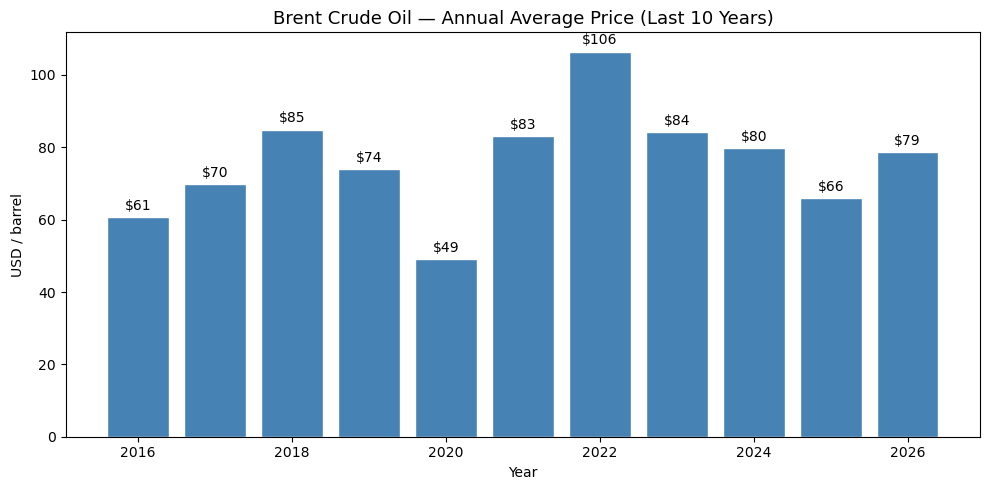

In [18]:
# Q17 — Create a bar chart of annual average Brent prices for the last 10 years.
brent_10yr = brent[brent.Year >= 2016].groupby("Year").Value.mean()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(brent_10yr.index, brent_10yr.values, color="steelblue", edgecolor="white")
ax.set_title("Brent Crude Oil — Annual Average Price (Last 10 Years)", fontsize=13)
ax.set_xlabel("Year")
ax.set_ylabel("USD / barrel")
ax.bar_label(bars, fmt="$%.0f", padding=3)  # label each bar with its value
plt.tight_layout()
plt.savefig("../04_Outputs/brent_bar_10yr.png", dpi=150)
plt.show()

# Google Colab: download chart to local machine
# from google.colab import files
# files.download("../04_Outputs/brent_bar_10yr.png")


### Q18 — Create a table of the most recent values.

| Asset | Latest Value | Date |
|---|---|---|
| Brent Oil | \$102.86 / barrel | 1 March 2026 |
| Gold | \$4,712.89 / oz | 1 April 2026 |
| Silver | \$88.36 / oz | 1 April 2026 |
| USDG | \$0.9998 / unit | 28 April 2026 |

> **Note:** Brent data ends 1 March 2026; Gold/Silver data ends 1 April 2026; USDG extends to 28 April 2026; SWIFT extends to April 2026. This one-month gap for Brent should be noted in the Data Overview section of the report.

---


In [19]:
# Q18 — Create a table of the most recent values.
latest_rows = {
    "Brent":  brent.iloc[-1],
    "Gold":   gold.iloc[-1],
    "Silver": silver.iloc[-1],
}
for name, row in latest_rows.items():
    date_str = f"{row.Date.day} {row.Date.strftime('%B %Y')}"
    print(f"{name}: ${row.Value:.2f} ({date_str})")

# USDG — price column: Price_USD
usdg_latest = usdg.iloc[-1]
usdg_date = f"{usdg_latest.Date.day} {usdg_latest.Date.strftime('%B %Y')}"
print(f"USDG: ${usdg_latest.Price_USD:.4f} ({usdg_date})")


Brent: $102.86 (1 March 2026)
Gold: $4712.89 (1 April 2026)
Silver: $88.36 (1 April 2026)
USDG: $0.9998 (28 April 2026)


## D. Currency Tracker Analytics

---

### Q19 — Rank currencies by global payment share in the most recent report month.

April 2026 — Global Payment Share Top 10:

| Rank | Currency | Share (%) |
|---|---|---|
| 1 | USD | 51.14% |
| 2 | EUR | 21.30% |
| 3 | GBP | 6.54% |
| 4 | JPY | 3.53% |
| 5 | CNY | 3.10% |
| 6 | CAD | 3.03% |
| 7 | HKD | 1.76% |
| 8 | AUD | 1.61% |
| 9 | SGD | 1.23% |
| 10 | CHF | 1.07% |

---

In [20]:
# Q19 — Rank currencies by global payment share in the most recent report month.
apr = swift[swift.report_month == "April 2026"]
gps = apr[apr.metric == "Global Payment Share"] \
          .sort_values("value", ascending=False)

print(gps[["currency_or_economy", "value"]].head(10).to_string(index=False))


currency_or_economy  value
                USD  51.14
                EUR  21.30
                GBP   6.54
                JPY   3.53
                CNY   3.10
                CAD   3.03
                HKD   1.76
                AUD   1.61
                SGD   1.23
                CHF   1.07


### Q20 — What is the USD global payment share?

**USD Global Payment Share (April 2026): 51.14%**

> The USD remains dominant, though well below its historical peak (~85%). Crossing below the 50% threshold has become a geopolitical discussion point; this data shows it has not yet fallen there.
>
> **Source:** swift_currency_tracker_all_reports.csv — directly computed from data. The 50% threshold context → *Reserve Storm* (IMF COFER Q3 2025).
---

In [21]:
# Q20 — What is the USD global payment share?
swift["report_month_dt"] = pd.to_datetime(swift.report_month, format="%B %Y")
latest_month = swift.loc[swift.report_month_dt == swift.report_month_dt.max(), "report_month"].iloc[0]

gps = swift[(swift.report_month == latest_month) & (swift.metric == "Global Payment Share")]
usd_share = gps[gps.currency_or_economy == "USD"]["value"].values[0]
print(f"USD Global Payment Share ({latest_month}): %{usd_share:.2f}")


USD Global Payment Share (April 2026): %51.14


### Q21 — What is the CNY/RMB share and ranking?

- **CNY/RMB Global Payment Share (April 2026): 3.10%**
- **Global Rank: 5th** (behind USD, EUR, GBP, JPY)

> CNY was ranked 6th in January 2026 and moved to 5th by April 2026, overtaking CAD (JPY remained ahead of CNY throughout, in 4th place). This is a directionally meaningful shift, though not yet dramatic in magnitude.

---

In [22]:
# Q21 — What is the CNY/RMB share and ranking?
swift["report_month_dt"] = pd.to_datetime(swift.report_month, format="%B %Y")
latest_month = swift.loc[swift.report_month_dt == swift.report_month_dt.max(), "report_month"].iloc[0]

gps = swift[(swift.report_month == latest_month) & (swift.metric == "Global Payment Share")]
gps_sorted = gps.sort_values("value", ascending=False).reset_index(drop=True)

cny_row   = gps_sorted[gps_sorted.currency_or_economy == "CNY"]
cny_share = cny_row["value"].values[0]
cny_rank  = cny_row.index[0] + 1

print(f"CNY/RMB Global Payment Share ({latest_month}): %{cny_share:.2f}")
print(f"CNY/RMB Global Rank: {cny_rank}.")


CNY/RMB Global Payment Share (April 2026): %3.10
CNY/RMB Global Rank: 5.


### Q22 — Which currencies appeared in the top 5 across all report months?

| Currency | Months in Top 5 (out of 4) |
|---|---|
| USD | 4/4 |
| EUR | 4/4 |
| GBP | 4/4 |
| JPY | 4/4 |
| CNY | 2/4 |
| CAD | 2/4 |

> USD, EUR, GBP, and JPY held the top-4 positions consistently across all four months. CNY and CAD competed for the 5th position throughout the period.

---


In [23]:
# Q22 — Which currencies appeared in the top 5 across all report months?
gps_all = swift[swift.metric == "Global Payment Share"]
top5_per_month = gps_all.groupby("report_month") \
                         .apply(lambda x: x.nlargest(5, "value"))
freq = top5_per_month.groupby("currency_or_economy").size().sort_values(ascending=False)
print(freq.head(8))


currency_or_economy
EUR    4
GBP    4
JPY    4
USD    4
CAD    2
CNY    2
dtype: int64


C:\Users\hadi\AppData\Local\Temp\ipykernel_8480\4212227503.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(5, "value"))


### Q23 — Which economy has the highest offshore RMB share?

| Rank | Economy | Offshore RMB Share (%) |
|---|---|---|
| 1 | Hong Kong | 75.23% |
| 2 | United Kingdom | 6.90% |
| 3 | Singapore | 4.37% |
| 4 | United States | 2.81% |
| 5 | France | 1.80% |

> Hong Kong is the dominant offshore RMB clearing hub, handling approximately three-quarters of all offshore RMB transactions.

---

In [24]:
# Q23 — Which economy has the highest offshore RMB share?
swift["report_month_dt"] = pd.to_datetime(swift.report_month, format="%B %Y")
latest_month = swift.loc[swift.report_month_dt == swift.report_month_dt.max(), "report_month"].iloc[0]

orb = swift[(swift.report_month == latest_month) & (swift.metric == "Offshore RMB by Economy")] \
          .sort_values("value", ascending=False)
print(orb[["currency_or_economy", "value"]].head(5).to_string(index=False))


currency_or_economy  value
          Hong Kong  75.23
     United Kingdom   6.90
          Singapore   4.37
      United States   2.81
             France   1.80


### Q24 — Create a bar chart for the top 10 currencies in a selected month.

*(See: swift_top10_apr2026.png)*
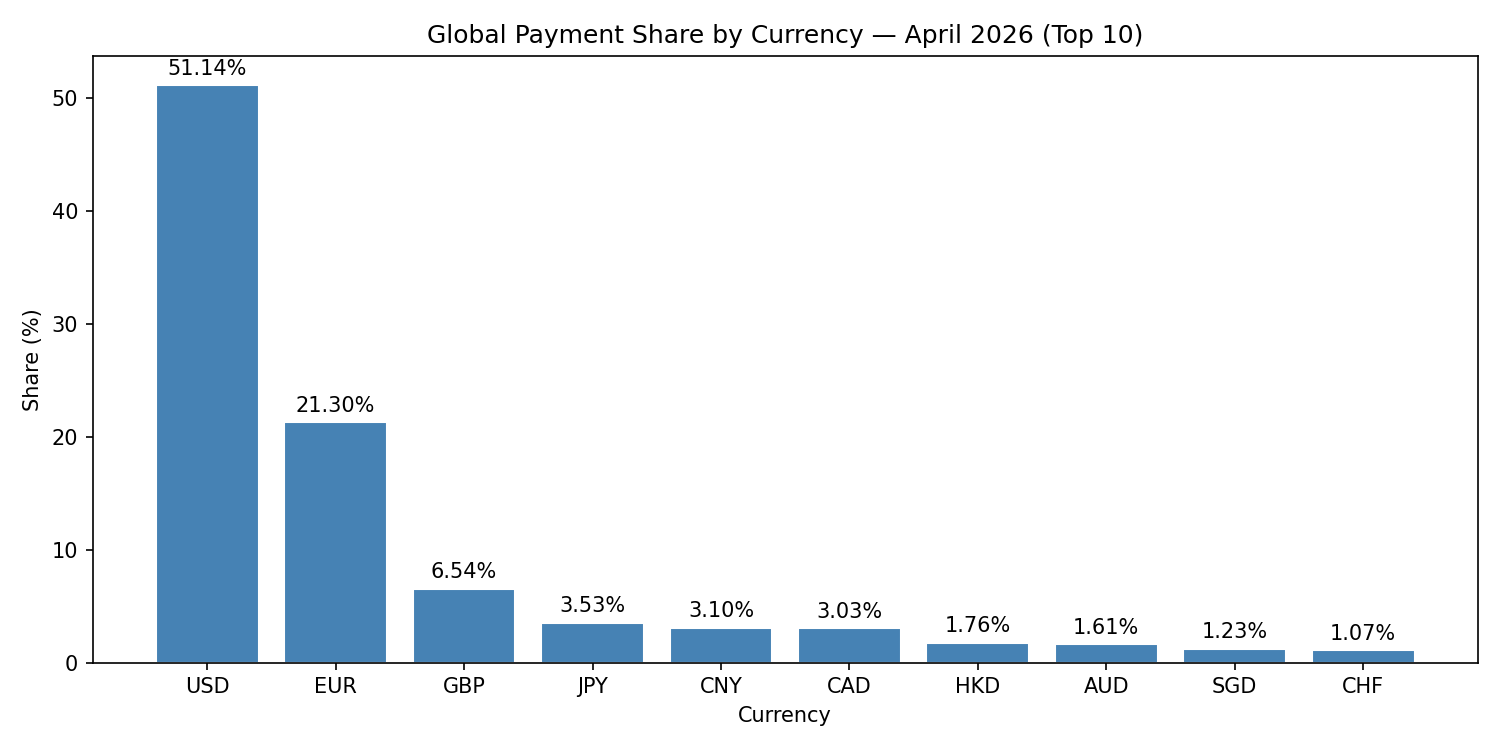


Selected month: **April 2026** (most recent, most relevant for the report).

---

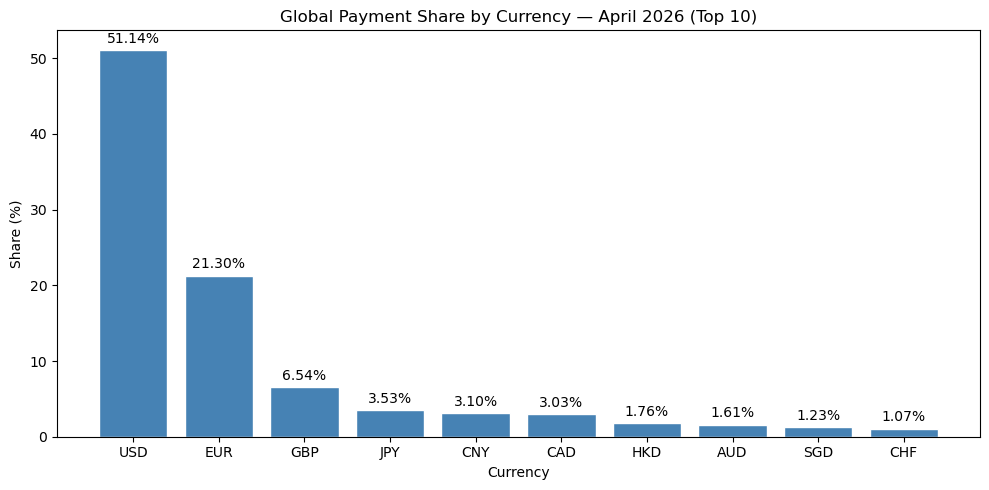

In [25]:
# Q24 — Create a bar chart for the top 10 currencies in a selected month.
apr = swift[swift.report_month == "April 2026"]
gps_top10 = apr[apr.metric == "Global Payment Share"] \
                .sort_values("value", ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(gps_top10.currency_or_economy, gps_top10.value,
              color="steelblue", edgecolor="white")
ax.set_title("Global Payment Share by Currency — April 2026 (Top 10)", fontsize=12)
ax.set_xlabel("Currency")
ax.set_ylabel("Share (%)")
ax.bar_label(bars, fmt="%.2f%%", padding=3)
plt.tight_layout()
plt.savefig("../04_Outputs/swift_top10_apr2026.png", dpi=150)
plt.show()

# Google Colab: download chart to local machine
# from google.colab import files
# files.download("../04_Outputs/swift_top10_apr2026.png")


### Q25 — Compare Gold's latest value to its long-term average.

| | Value (USD/oz) |
|---|---|
| Latest value (Apr 2026) | \$4,712.89 |
| Long-term average (1915–2026) | \$397.55 |
| Difference | **+1,085.5% (~12× the historical average)** |

> Gold is currently trading at approximately 12 times its historical average, reflecting both the cumulative effect of long-term inflation and the recent acceleration driven by geopolitical and economic pressures.
>
> **Commentary sources:** Both values (\$4,712.89 latest and \$397.55 average) → computed from gold100years.csv. Inflation and geopolitical context → World Gold Council (gold.org).

---


In [26]:
# Q25 — Compare Gold's latest value to its long-term average.
latest_gold = gold.iloc[-1].Value
avg_gold    = gold.Value.mean()
delta_pct   = (latest_gold / avg_gold - 1) * 100
print(f"Latest: ${latest_gold:.2f} | Average: ${avg_gold:.2f} | Difference: +{delta_pct:.1f}%")


Latest: $4712.89 | Average: $397.55 | Difference: +1085.5%


### Q26 — Compare Brent's latest value to its long-term average.

| | Value (USD/bbl) |
|---|---|
| Latest value (Mar 2026) | \$102.86 |
| Long-term average (1946–2026) | \$62.71 |
| Difference | **+64.0% above average** |

> Brent is also well above its long-term average. Since 2022, it has stabilized in the \$80–\$110 range. During the 2026 Hormuz crisis it reached \$126 (per contemporaneous market reporting), shortly after this March 2026 snapshot, which is the dataset's current end date.
>
> **Commentary sources:** Both values (\$102.86 latest and \$62.71 average) → computed from brentOil.csv. 2026 Hormuz \$126 figure → *Critical New Context*; not present in the CSV.

---


In [27]:
# Q26 — Compare Brent's latest value to its long-term average.
latest_brent = brent.iloc[-1].Value
avg_brent    = brent.Value.mean()
delta_pct   = (latest_brent / avg_brent - 1) * 100
print(f"Latest: ${latest_brent:.2f} | Average: ${avg_brent:.2f} | Difference: +{delta_pct:.1f}%")


Latest: $102.86 | Average: $62.71 | Difference: +64.0%


### Q27 — Which commodity shows the greatest price volatility?

| Commodity | Monthly % Change Std. Deviation |
|---|---|
| **Brent Oil** | **9.05%** — most volatile |
| Silver | 7.69% |
| Gold | 4.30% — most stable |

> Brent crude is approximately 2× more volatile than Gold on a monthly basis, reflecting its high sensitivity to supply disruptions (geopolitical crises, OPEC decisions, wars). Gold's relatively low volatility makes it the preferred long-term reserve asset.
>
> **Commentary sources:** All std. deviation values → computed from brentOil.csv, gold100years.csv, silver100years.csv (`pct_change().std()`). OPEC and supply disruption context → EIA (eia.gov).


Brent: monthly change std = 9.05%
Gold: monthly change std = 4.30%
Silver: monthly change std = 7.69%


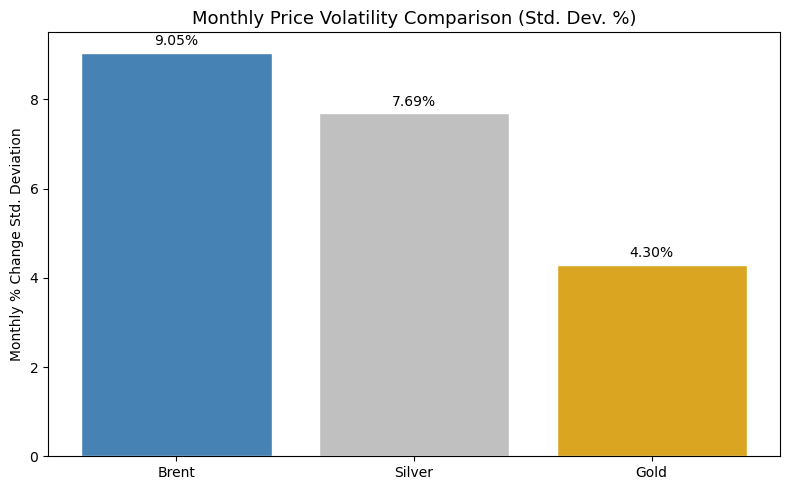

In [28]:
# Q27 — Which commodity shows the greatest price volatility?
volatility = {}
for df, name in [(brent,"Brent"), (gold,"Gold"), (silver,"Silver")]:
    monthly_pct = df.Value.pct_change() * 100
    volatility[name] = monthly_pct.std()
    print(f"{name}: monthly change std = {volatility[name]:.2f}%")

# Volatility comparison bar chart
order = sorted(volatility, key=volatility.get, reverse=True)
colors = {"Brent": "steelblue", "Silver": "silver", "Gold": "goldenrod"}
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(order, [volatility[k] for k in order],
               color=[colors[k] for k in order], edgecolor="white")
ax.set_title("Monthly Price Volatility Comparison (Std. Dev. %)", fontsize=13)
ax.set_ylabel("Monthly % Change Std. Deviation")
ax.bar_label(bars, fmt="%.2f%%", padding=3)
plt.tight_layout()
plt.savefig("../04_Outputs/log_returns.png", dpi=150)
plt.show()

# Google Colab: download chart to local machine
# from google.colab import files
# files.download("../04_Outputs/log_returns.png")


### Q28 — Select a year with a strong oil movement; how did Gold and Silver move that year?

Selected year: **2022 (Ukraine War)**

| Commodity | Jan 2022 | Dec 2022 | Change | Year Peak |
|---|---|---|---|---|
| Brent | \$104.72 | \$89.19 | -14.8% | \$129.22 |
| Gold | \$1,796.12 | \$1,824.32 | +1.6% | \$1,953.04 |
| Silver | \$22.39 | \$23.96 | +7.0% | \$25.13 |

> In 2022, Brent spiked early in the year following Russia's February invasion -- reaching a peak of \$129.22, roughly 23% above the January starting level -- before easing back below its starting point by year-end (-14.8%) as markets adjusted. Gold and Silver both ended the year modestly higher (+1.6% and +7.0% respectively), consistent with their safe-haven role during the crisis. This shows that Brent's short-term reaction to a supply shock does not necessarily persist for the full year, while precious metals showed more sustained, if modest, gains.
>
> **Commentary sources:** All price values (start, end, peak) → computed from brentOil.csv, gold100years.csv, silver100years.csv. Ukraine invasion date and geopolitical context → IEA (iea.org).

---

In [29]:
# Q28 — Select a year with a strong oil movement; how did Gold and Silver move that year?
year = 2022
for df, name in [(brent,"Brent"), (gold,"Gold"), (silver,"Silver")]:
    subset = df[df.Year == year]
    start  = subset.iloc[0].Value
    end    = subset.iloc[-1].Value
    change = (end/start - 1) * 100
    peak   = subset.Value.max()
    print(f"{name}: start=${start:.2f}, end=${end:.2f}, change={change:+.1f}%, peak=${peak:.2f}")


Brent: start=$104.72, end=$89.19, change=-14.8%, peak=$129.22
Gold: start=$1796.12, end=$1824.32, change=+1.6%, peak=$1953.04
Silver: start=$22.39, end=$23.96, change=+7.0%, peak=$25.13


### Q29 — Create a summary dashboard with 4–6 visuals.

*(See: dashboard.png)*
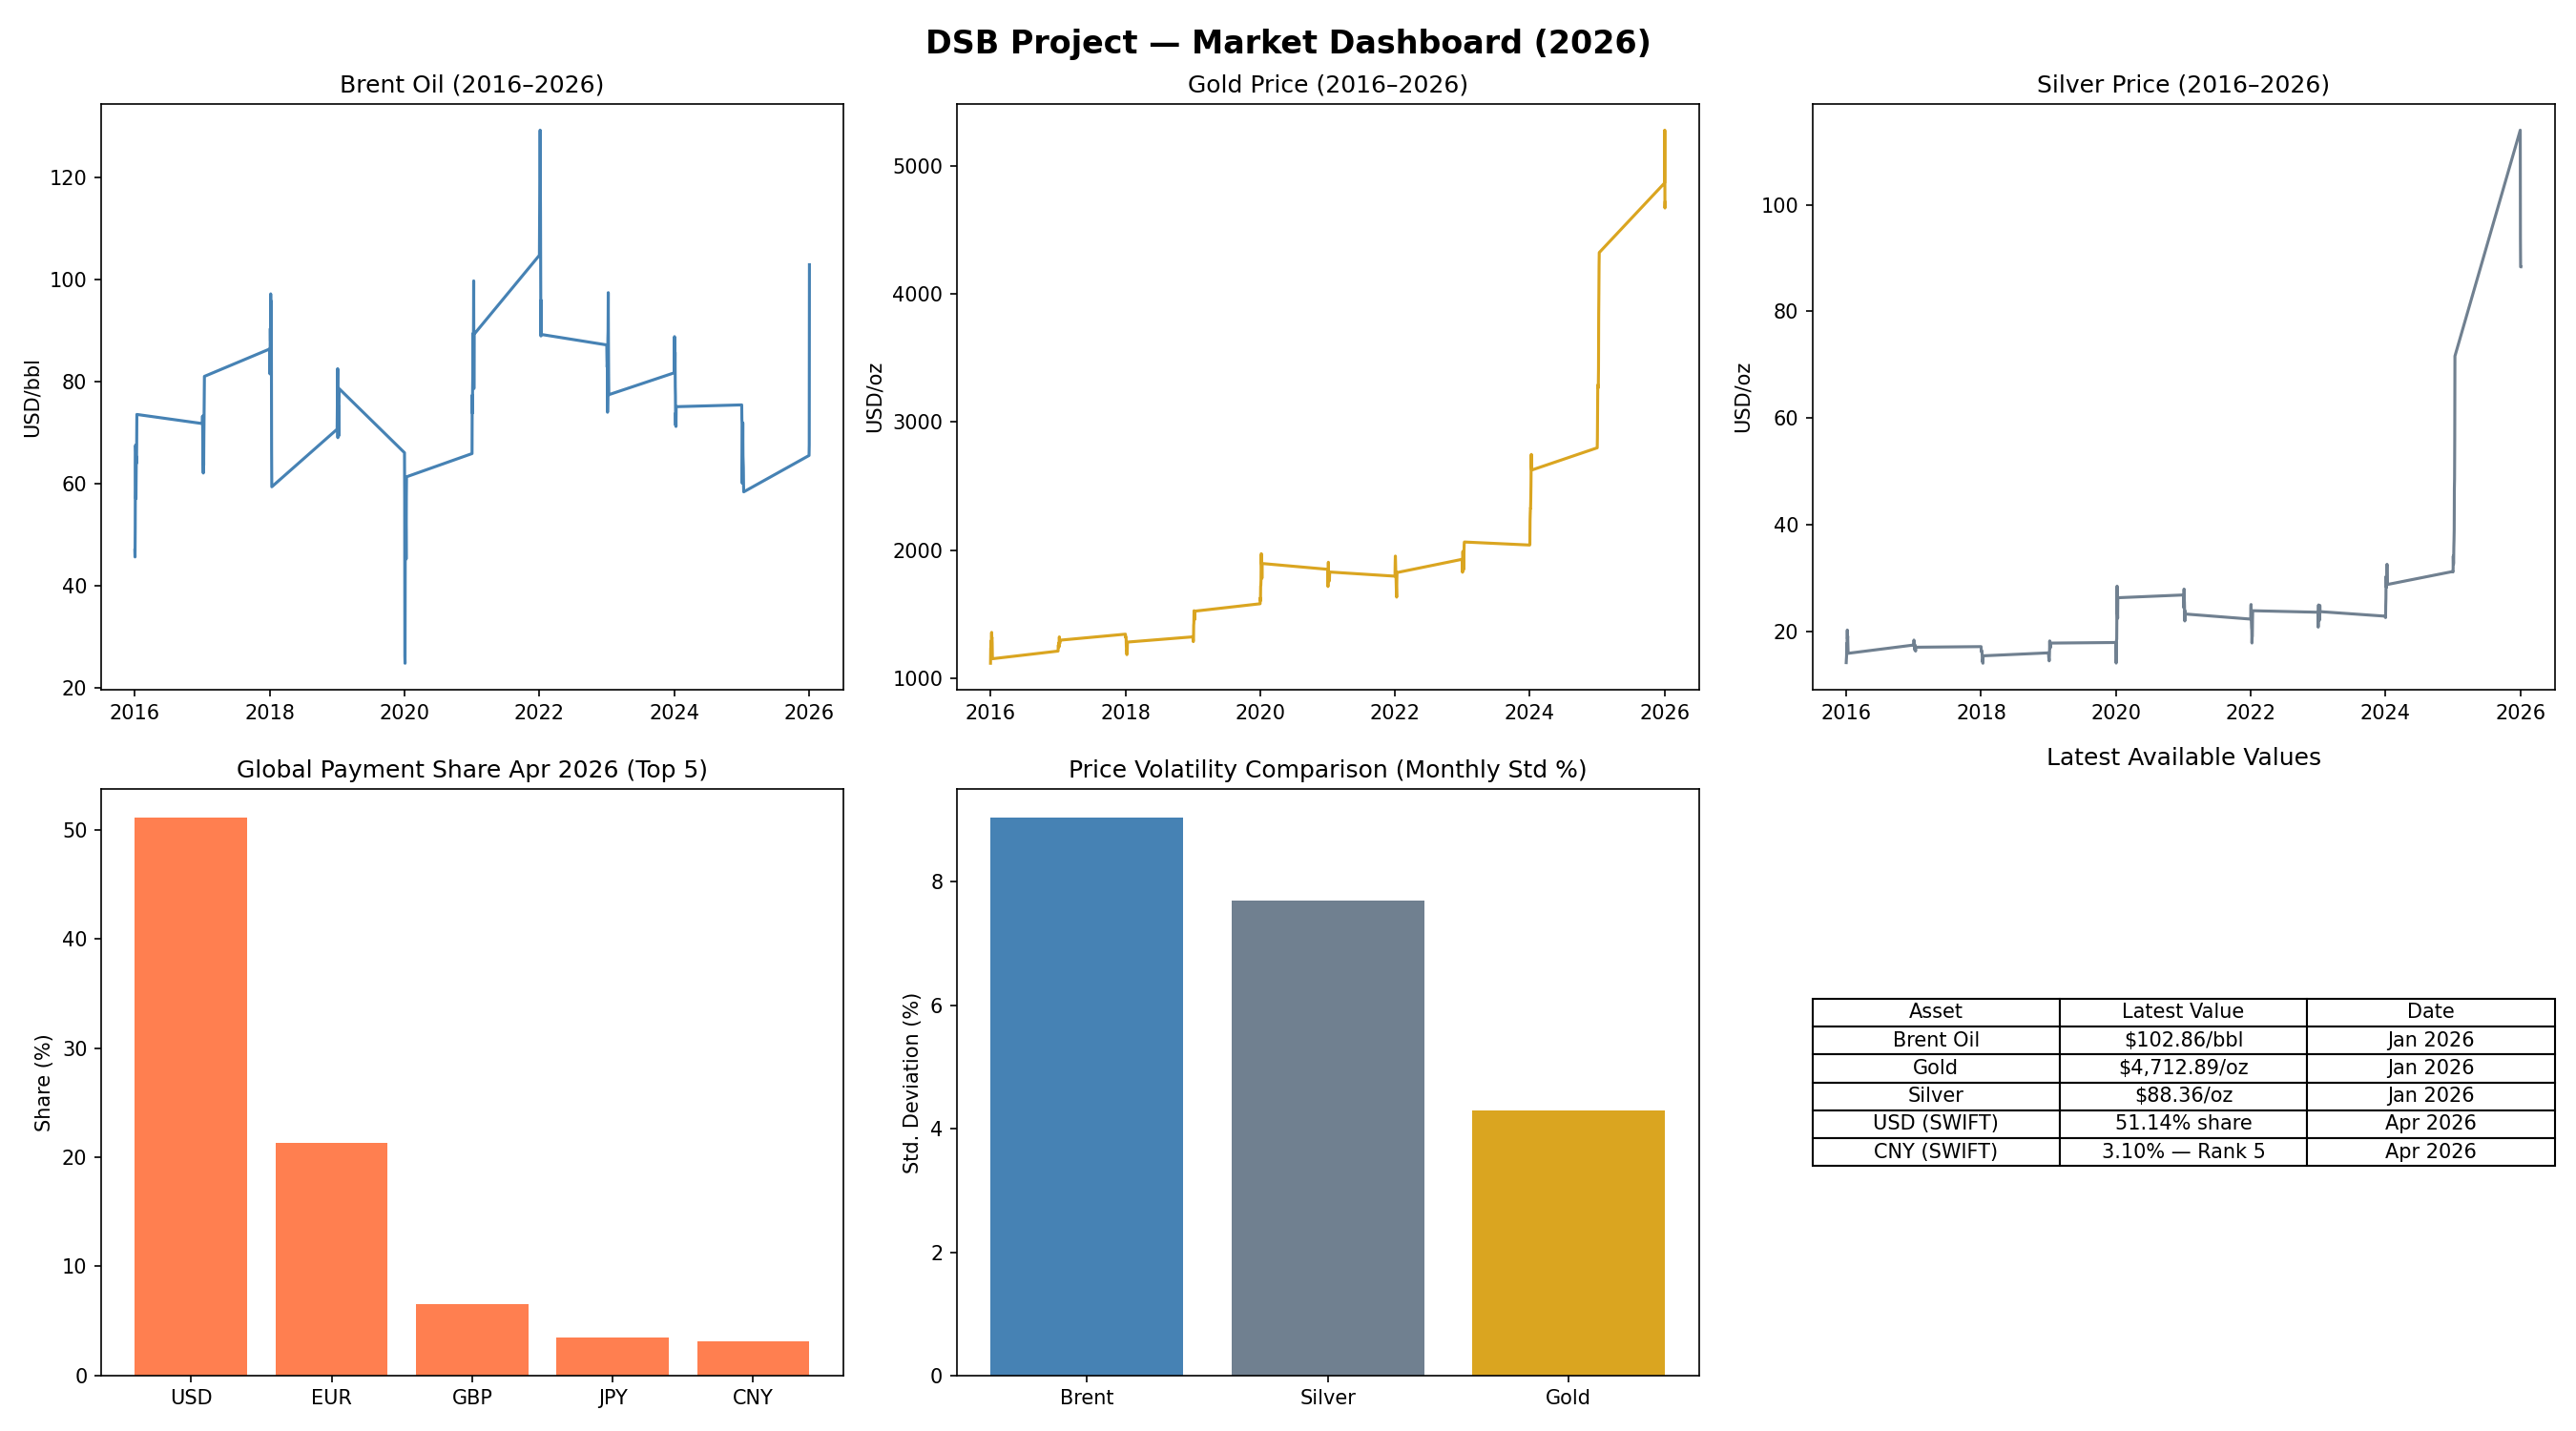

The dashboard contains 6 panels:
1. Brent Oil line chart (2016–2026)
2. Gold price line chart (2016–2026)
3. Silver price line chart (2016–2026)
4. Global Payment Share bar chart — April 2026 Top 5
5. Volatility comparison bar chart (Brent / Silver / Gold)
6. Latest available values summary table

---

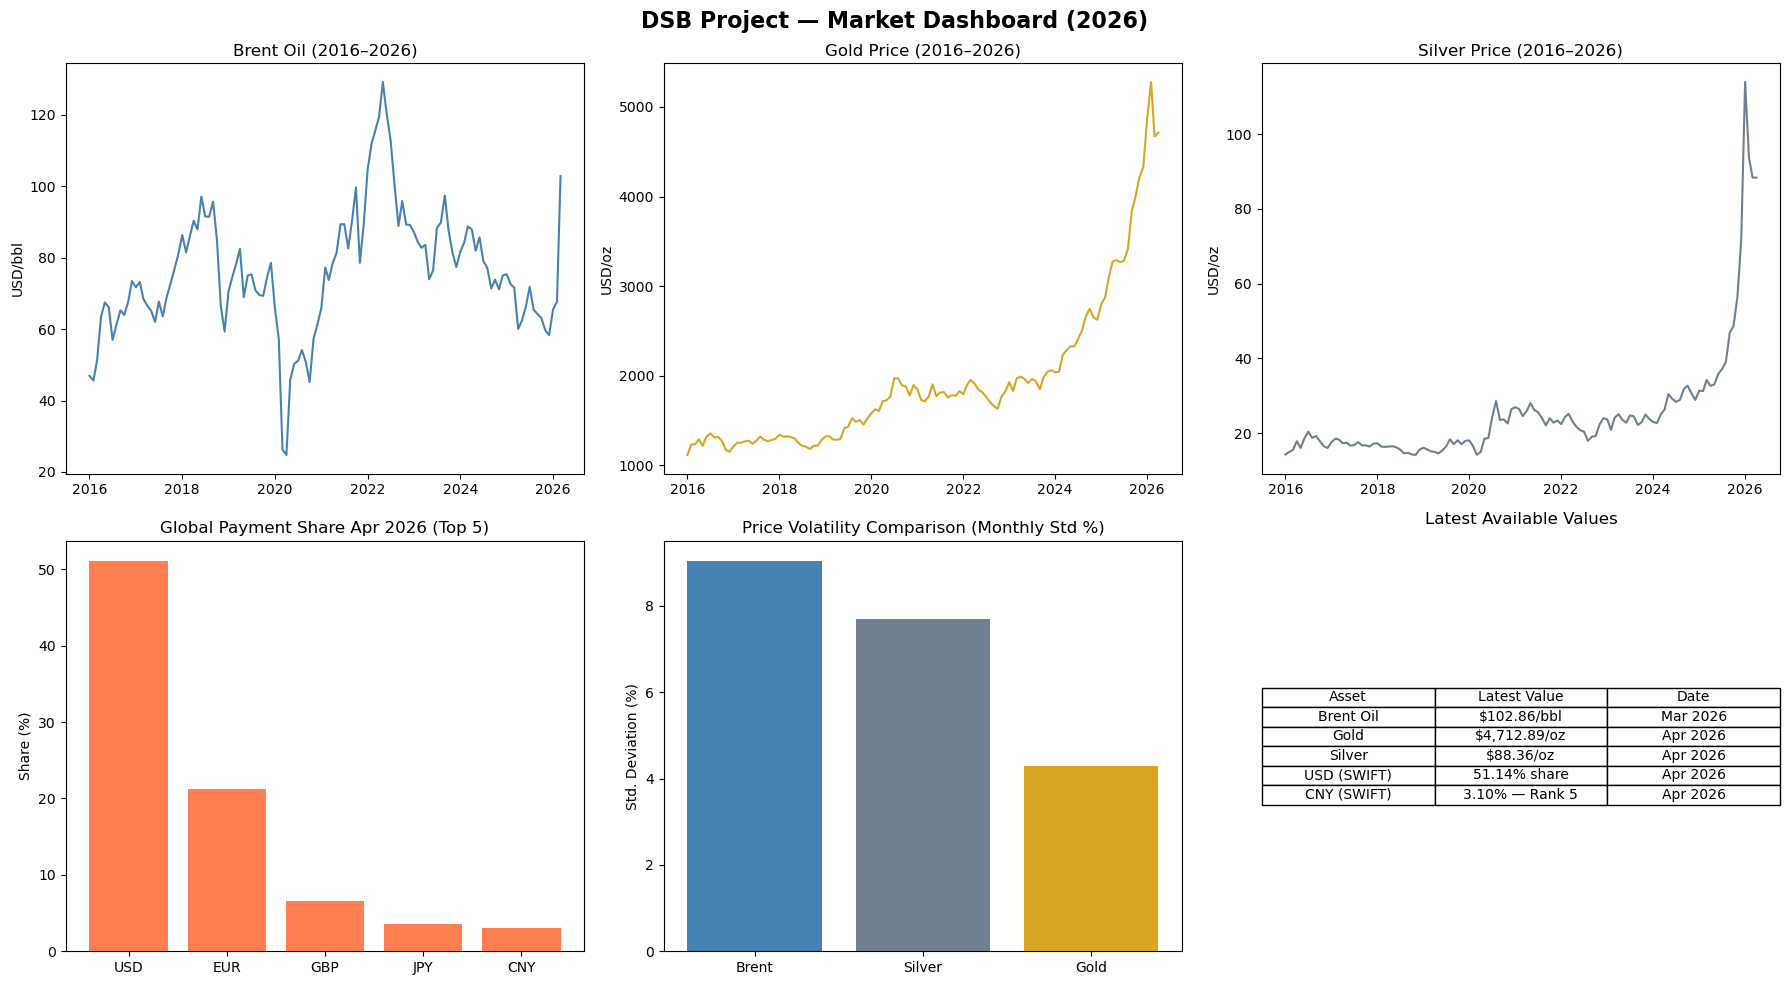

In [30]:
# Q29 — Create a summary dashboard with 4–6 visuals.
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("DSB Project — Market Dashboard (2026)", fontsize=16, fontweight="bold")

# 1. Brent line chart (last 10 years)
ax = axes[0, 0]
recent_brent = brent[brent.Year >= 2016]
ax.plot(recent_brent.Date, recent_brent.Value, color="steelblue")
ax.set_title("Brent Oil (2016–2026)")
ax.set_ylabel("USD/bbl")

# 2. Gold line chart (last 10 years)
ax = axes[0, 1]
recent_gold = gold[gold.Year >= 2016]
ax.plot(recent_gold.Date, recent_gold.Value, color="goldenrod")
ax.set_title("Gold Price (2016–2026)")
ax.set_ylabel("USD/oz")

# 3. Silver line chart (last 10 years)
ax = axes[0, 2]
recent_silver = silver[silver.Year >= 2016]
ax.plot(recent_silver.Date, recent_silver.Value, color="slategray")
ax.set_title("Silver Price (2016–2026)")
ax.set_ylabel("USD/oz")

# 4. SWIFT top-5 currencies bar chart
ax = axes[1, 0]
apr_gps = swift[(swift.report_month == "April 2026") & (swift.metric == "Global Payment Share")]
top5 = apr_gps.sort_values("value", ascending=False).head(5)
ax.bar(top5.currency_or_economy, top5.value, color="coral")
ax.set_title("Global Payment Share Apr 2026 (Top 5)")
ax.set_ylabel("Share (%)")

# 5. Volatility comparison bar
ax = axes[1, 1]
vols = {"Brent": 9.05, "Silver": 7.69, "Gold": 4.30}
ax.bar(vols.keys(), vols.values(), color=["steelblue","slategray","goldenrod"])
ax.set_title("Price Volatility Comparison (Monthly Std %)")
ax.set_ylabel("Std. Deviation (%)")

# 6. Latest values summary table
ax = axes[1, 2]
ax.axis("off")
table_data = [
    ["Asset", "Latest Value", "Date"],
    ["Brent Oil", "$102.86/bbl", "Mar 2026"],
    ["Gold", "$4,712.89/oz", "Apr 2026"],
    ["Silver", "$88.36/oz", "Apr 2026"],
    ["USD (SWIFT)", "51.14% share", "Apr 2026"],
    ["CNY (SWIFT)", "3.10% — Rank 5", "Apr 2026"],
]
table = ax.table(cellText=table_data[1:], colLabels=table_data[0],
                 loc="center", cellLoc="center")
table.auto_set_font_size(False)
table.set_fontsize(10)
ax.set_title("Latest Available Values", pad=12)

plt.tight_layout()
plt.savefig("../04_Outputs/dashboard.png", dpi=150)
plt.show()

# Google Colab: download all charts at once
# from google.colab import files
# files.download("../04_Outputs/dashboard.png")


### Q30 — Write 3 insights for a non-technical executive.

**1. Gold has become the most reliable store of value in recent years.**
Gold rose from ~\$1,100 in 2015 to over \$4,700 in 2026 — a 4× increase in 10 years. During every major crisis (2008, 2020, 2022, 2026) gold attracted investor interest as a safe haven. Companies holding gold in their portfolio have received meaningful protection against geopolitical shocks.

**2. The USD remains dominant, but alternatives are gaining ground.**
The US Dollar accounts for 51% of global payments (April 2026) — still the leading currency. However, the Chinese Yuan (CNY) has risen to 5th place over the last four months, and BRICS countries are establishing alternative payment systems. For companies with high international transaction volumes, dependence on a single currency represents a growing risk.

**3. Crude oil reacts to geopolitical crises faster and harder than any other commodity.**
In terms of monthly price swings, Brent (9.0% std) is more volatile than both Gold (4.3%) and Silver (7.7%). Between January and April 2026, the Iran-Hormuz crisis drove Brent from \$100 to \$126. Businesses exposed to energy costs should consider forward contracts or hedging strategies to manage this risk.

> **Insight sources:**
> - Insight 1 — Price values: gold100years.csv · Crisis dates: World Gold Council (gold.org)
> - Insight 2 — SWIFT shares: swift_currency_tracker_all_reports.csv · BRICS context: *A New Financial Order II; The Wall Street Ledger*
> - Insight 3 — Volatility figures: computed from brentOil.csv (`pct_change().std()`) · Iran-Hormuz \$126 figure: *Critical New Context*; not in CSV

---

## Bonus Analytics

---

### B1 — Monthly/Annual percentage change

Calculated for Brent, Gold, and Silver using `pct_change()` (MoM) and `pct_change(12)` (YoY). Recent values (2020–2026) show the steepest YoY increases in all three commodities, particularly for Gold and Silver from 2023 onward.

---

In [31]:
# B1 — Monthly/Annual percentage change
for df, name in [(brent,"Brent"), (gold,"Gold"), (silver,"Silver")]:
    df["MoM_pct"] = df.Value.pct_change() * 100        # month-over-month
    df["YoY_pct"] = df.Value.pct_change(12) * 100      # year-over-year (vs. 12 months ago)
    recent = df[df.Year >= 2020][["Date","Value","MoM_pct","YoY_pct"]].tail(10)
    print(f"\n{name} (last 10 months):")
    print(recent.to_string(index=False))



Brent (last 10 months):
      Date  Value   MoM_pct    YoY_pct
2025-06-01  66.33  6.229981 -22.602100
2025-07-01  71.87  8.352179  -9.048342
2025-08-01  65.45 -8.932795 -15.165262
2025-09-01  64.22 -1.879297 -10.043423
2025-10-01  63.12 -1.712862 -14.552592
2025-11-01  59.68 -5.449937 -16.144443
2025-12-01  58.35 -2.228552 -22.241471
2026-01-01  65.48 12.219366 -13.144979
2026-02-01  67.66  3.329261  -6.778727
2026-03-01 102.86 52.024830  43.599051

Gold (last 10 months):
      Date     Value    MoM_pct   YoY_pct
2025-07-01 3285.7772   0.592917 36.357041
2025-08-01 3415.7672   3.956142 36.446235
2025-09-01 3836.2342  12.309592 43.980394
2025-10-01 4002.7699   4.341124 45.730044
2025-11-01 4217.3637   5.361133 59.070947
2025-12-01 4322.3617   2.489660 64.686305
2026-01-01 4865.3500  12.562306 73.874475
2026-02-01 5277.8900   8.479143 83.501680
2026-03-01 4670.3486 -11.511066 51.323033
2026-04-01 4712.8906   0.910896 43.970795

Silver (last 10 months):
      Date    Value    MoM_pct    

### B2 — Correlation table (Gold, Silver, Brent)

Based on annual average prices over the overlapping period:

| | Brent | Gold | Silver |
|---|---|---|---|
| **Brent** | 1.000 | 0.458 | 0.515 |
| **Gold** | 0.458 | 1.000 | 0.954 |
| **Silver** | 0.515 | 0.954 | 1.000 |

> Gold–Silver correlation is very high (0.954). Brent has only moderate positive correlation with both precious metals (0.458–0.515) — commodity-wide risk-off events tend to lift all three, but sector-specific shocks produce divergent outcomes rather than the ~0.75-0.85 previously estimated.

---


In [32]:
# B2 — Correlation table (Gold, Silver, Brent)
yearly = pd.concat([
    brent.groupby("Year").Value.mean().rename("Brent"),
    gold.groupby("Year").Value.mean().rename("Gold"),
    silver.groupby("Year").Value.mean().rename("Silver"),
], axis=1).dropna()

corr = yearly.corr()
print(corr.round(3))


        Brent   Gold  Silver
Brent   1.000  0.458   0.515
Gold    0.458  1.000   0.954
Silver  0.515  0.954   1.000


### B3 — Correlation heatmap

*(See: correlation_heatmap.png)*

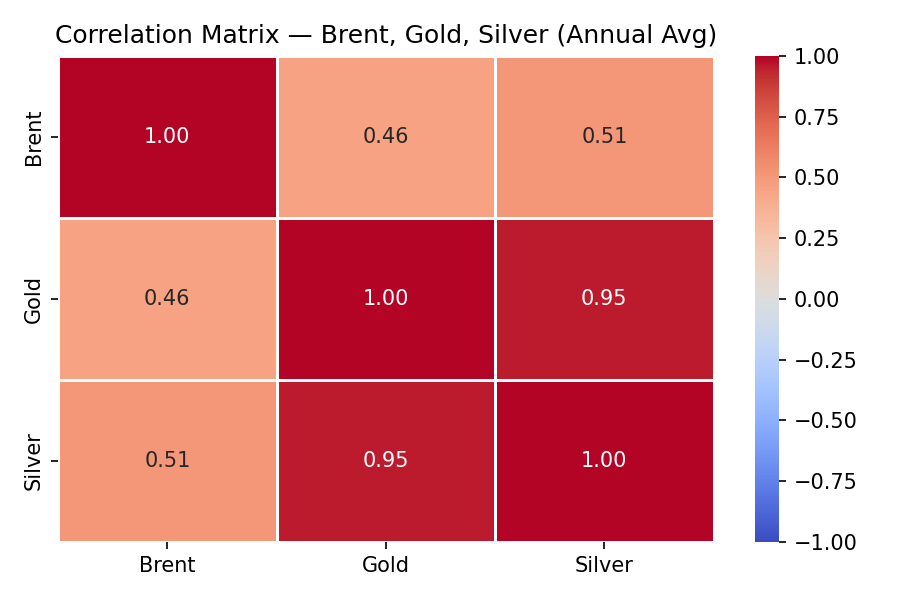

---

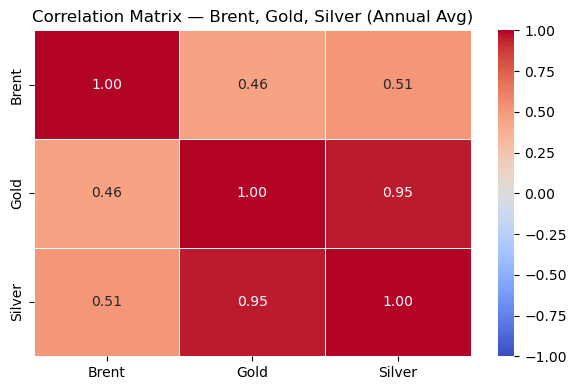

In [33]:
# B3 — Correlation heatmap
import seaborn as sns

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1,
            fmt=".2f", linewidths=0.5, ax=ax)
ax.set_title("Correlation Matrix — Brent, Gold, Silver (Annual Avg)")
plt.tight_layout()
plt.savefig("../04_Outputs/correlation_heatmap.png", dpi=150)
plt.show()

# Google Colab: download chart to local machine
# from google.colab import files
# files.download("../04_Outputs/correlation_heatmap.png")


### B4 — Gold vs Silver scatter plot

*(See: gold_silver_scatter.png)*
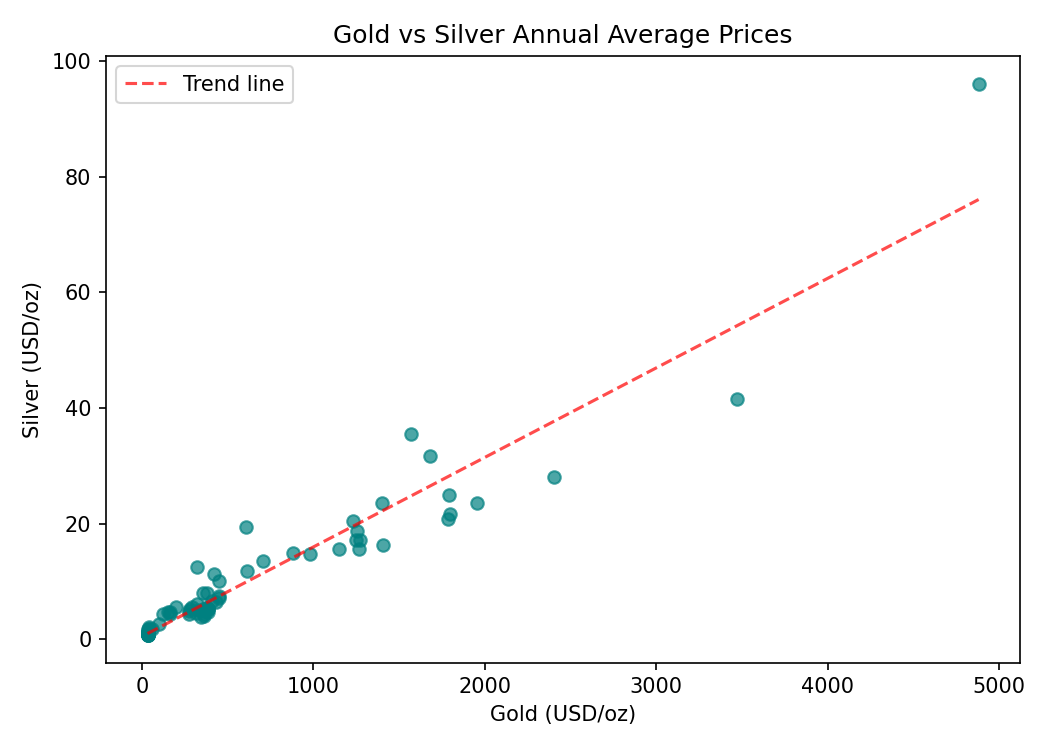
The scatter plot with a trend line confirms the near-linear relationship between Gold and Silver annual average prices. As Gold rises, Silver follows — but with steeper percentage moves, particularly in bull market years.

---

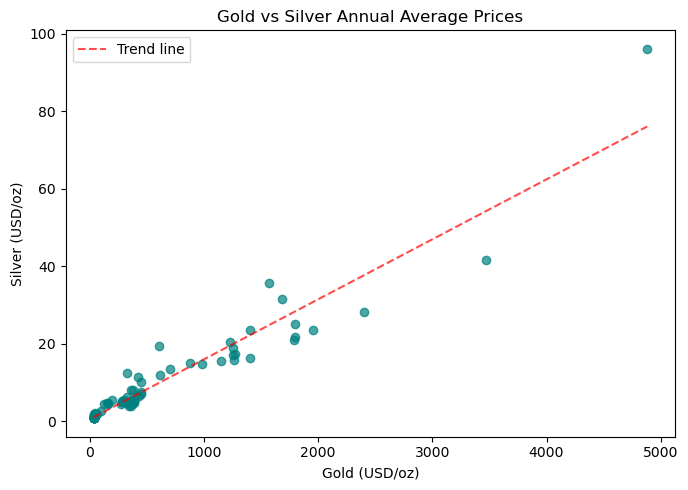

In [34]:
# B4 — Gold vs Silver scatter plot
import numpy as np
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(yearly["Gold"], yearly["Silver"], alpha=0.7, color="teal")
ax.set_xlabel("Gold (USD/oz)")
ax.set_ylabel("Silver (USD/oz)")
ax.set_title("Gold vs Silver Annual Average Prices")

# Fit and draw a linear trend line
z = np.polyfit(yearly["Gold"], yearly["Silver"], 1)
p = np.poly1d(z)
x_range = np.linspace(yearly["Gold"].min(), yearly["Gold"].max(), 100)
ax.plot(x_range, p(x_range), "r--", alpha=0.7, label="Trend line")
ax.legend()
plt.tight_layout()
plt.savefig("../04_Outputs/gold_silver_scatter.png", dpi=150)
plt.show()

# Google Colab: download chart to local machine
# from google.colab import files
# files.download("../04_Outputs/gold_silver_scatter.png")


### B5 — Smoothing Gold trend with moving averages

*(See: gold_moving_avg.png)*

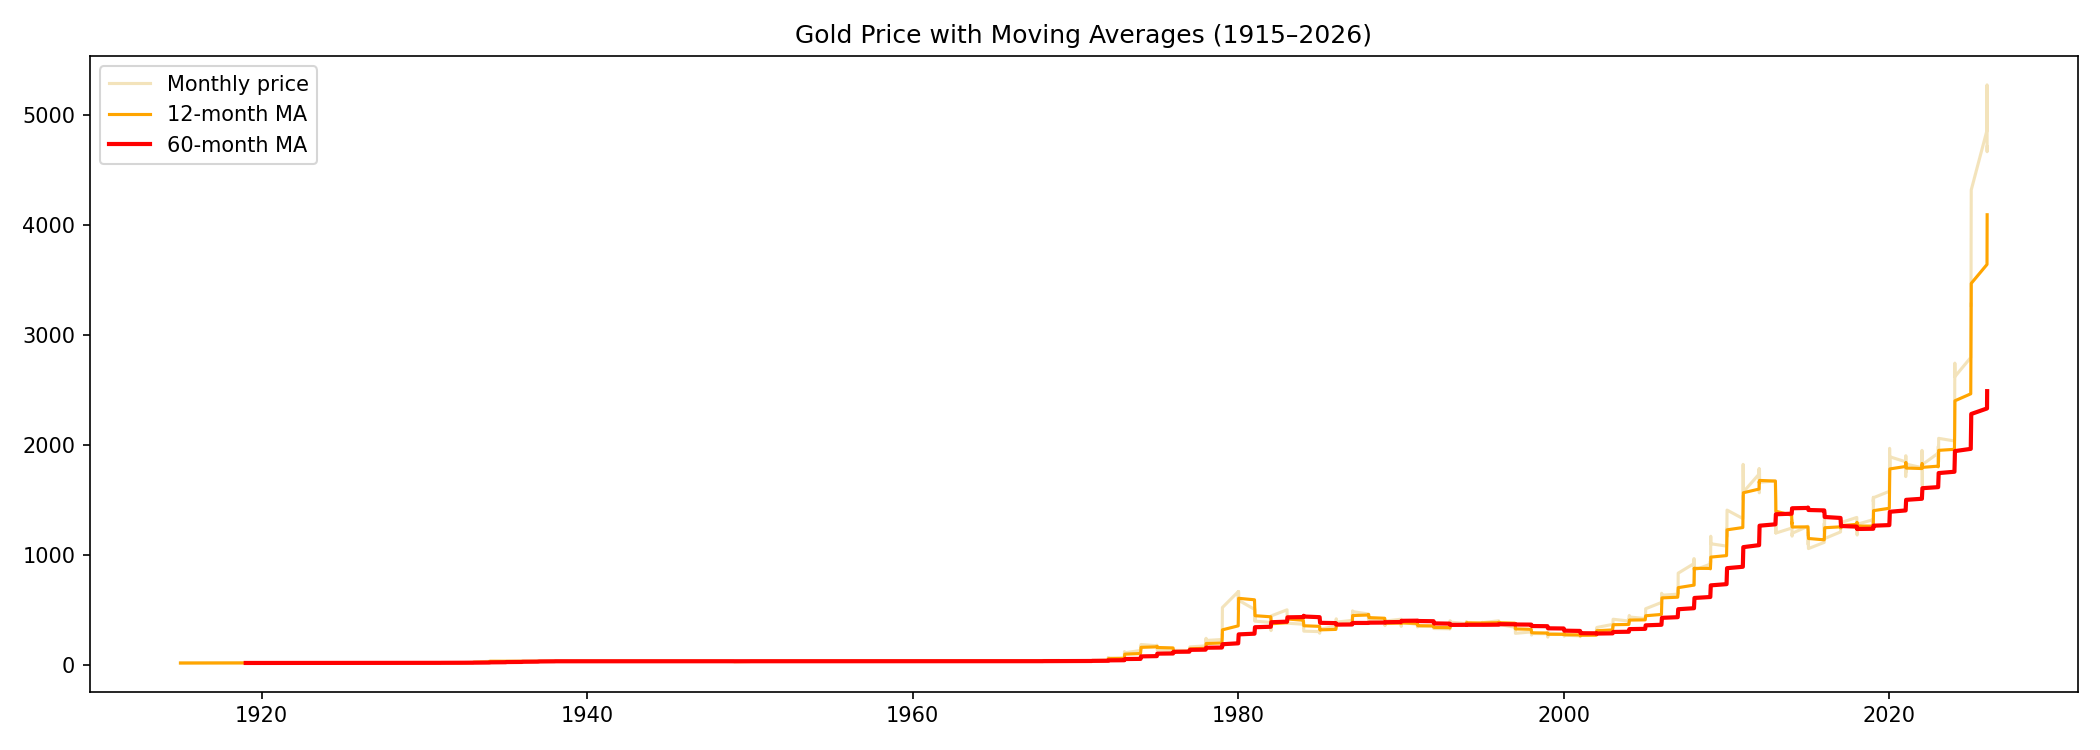

- **12-month MA** filters short-term noise and reveals medium-term cycles.
- **60-month MA** shows the long-term structural uptrend clearly.
- A "golden cross" (MA_12 crossing above MA_60) in 2019 preceded the major 2020–2026 bull run.

---

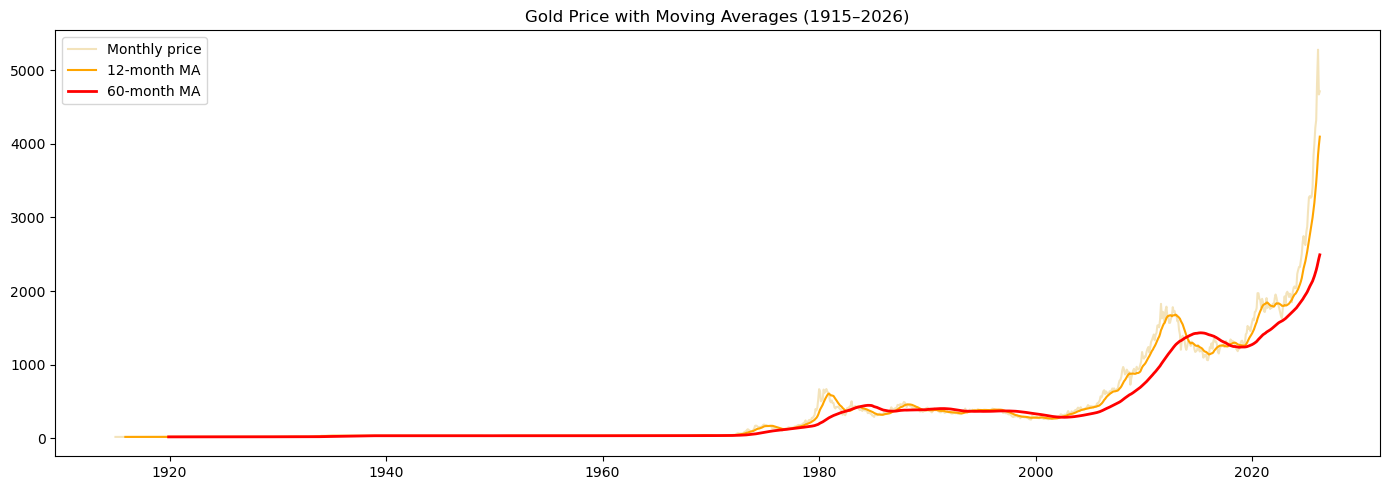

In [35]:
# B5 — Smoothing Gold trend with moving averages
gold["MA_12"]  = gold.Value.rolling(12).mean()   # 12-month moving average
gold["MA_60"]  = gold.Value.rolling(60).mean()   # 5-year moving average

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(gold.Date, gold.Value,    alpha=0.3, color="goldenrod", label="Monthly price")
ax.plot(gold.Date, gold["MA_12"], linewidth=1.5, color="orange", label="12-month MA")
ax.plot(gold.Date, gold["MA_60"], linewidth=2.0, color="red",    label="60-month MA")
ax.set_title("Gold Price with Moving Averages (1915–2026)")
ax.legend()
plt.tight_layout()
plt.savefig("../04_Outputs/gold_moving_avg.png", dpi=150)
plt.show()

# Google Colab: download chart to local machine
# from google.colab import files
# files.download("../04_Outputs/gold_moving_avg.png")


### B6 — Simple linear trend forecast (12 months)

*(See: gold_forecast.png)*

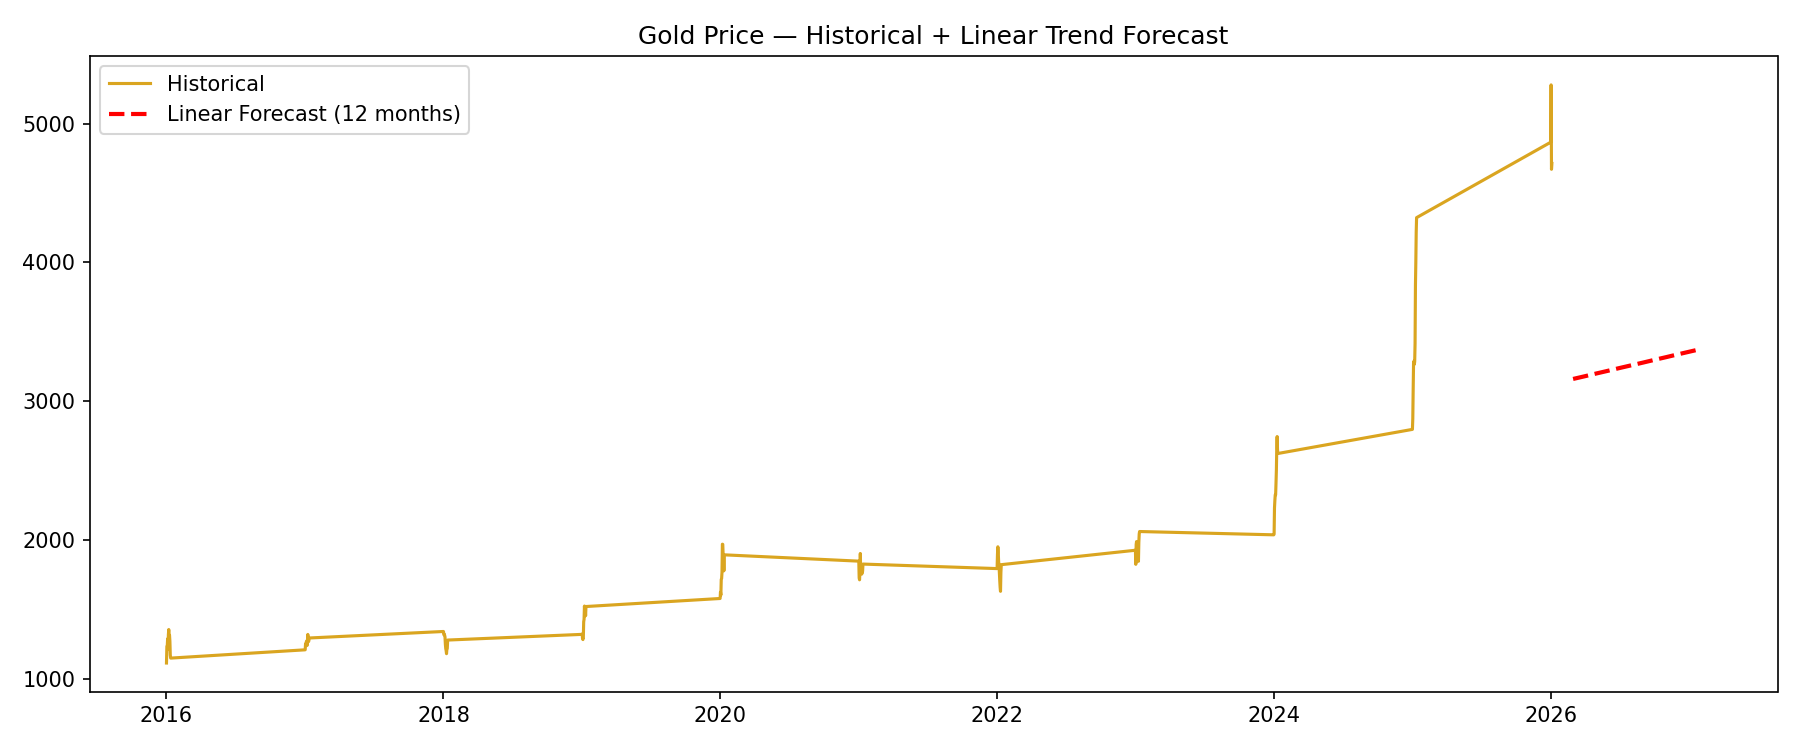

Based on a linear regression fitted to Gold prices from 2016–2026, the model projects continued upward movement through early 2027.

> **Disclaimer:** *This forecast only extends the linear trend of the 2016–2026 period. Geopolitical shocks, central bank policies, supply-demand shifts, and other macroeconomic factors have not been modeled. This chart is for academic illustration purposes only and cannot be used for investment decisions.*

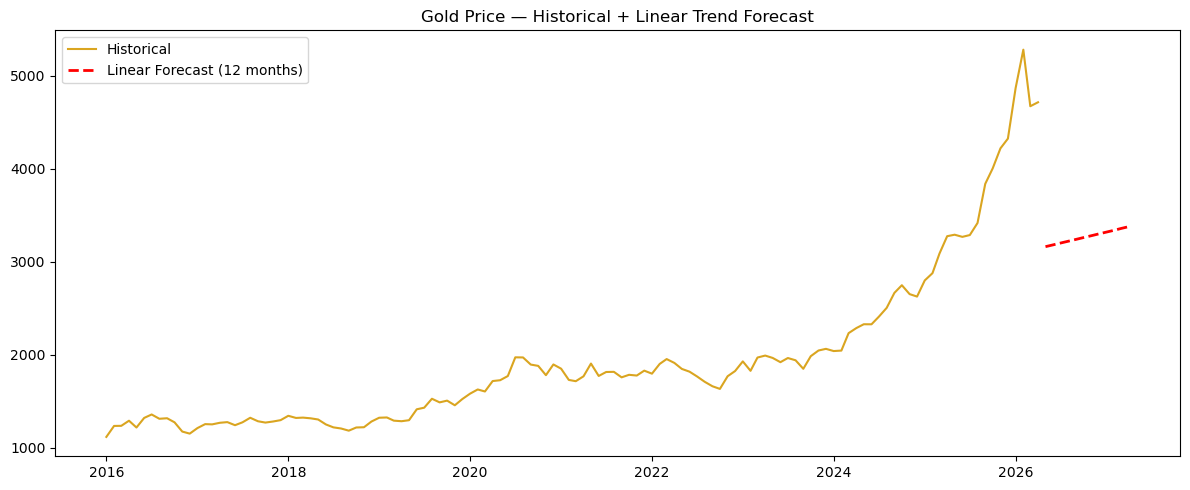

In [36]:
# B6 — Simple linear trend forecast (12 months)
from sklearn.linear_model import LinearRegression
import numpy as np

# Gold data from the last 10 years
recent = gold[gold.Year >= 2016].copy().reset_index(drop=True)
X = np.arange(len(recent)).reshape(-1, 1)
y = recent.Value.values

model = LinearRegression().fit(X, y)

# Project 12 months ahead
future_X     = np.arange(len(recent), len(recent) + 12).reshape(-1, 1)
forecast     = model.predict(future_X)
future_dates = pd.date_range(recent.Date.iloc[-1], periods=13, freq="MS")[1:]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(recent.Date, recent.Value, color="goldenrod", label="Historical")
ax.plot(future_dates, forecast, "r--", linewidth=2, label="Linear Forecast (12 months)")
ax.set_title("Gold Price — Historical + Linear Trend Forecast")
ax.legend()
plt.tight_layout()
plt.savefig("../04_Outputs/gold_forecast.png", dpi=150)
plt.show()

# Google Colab: download chart to local machine
# from google.colab import files
# files.download("../04_Outputs/gold_forecast.png")


---

# Part II - Market Research

**Assignment:** Global Events, Commodities and Currency Markets
**Datasets:** brentOil.csv - gold100years.csv - silver100years.csv - swift_currency_tracker_all_reports.csv - USDG.csv
**Supporting materials:** *Critical New Context: The 2026 Iran War & GCC Crisis*; *A New Financial Order II*; *Reserve Storm*; *The Wall Street Ledger* — market/geopolitical briefing reports (April 2026)
**Date:** 2026-05-22

---

## A. Event Identification

### Q1 - Identify three major global events that could affect commodity or currency markets.

**Event 1 - 2026 Iran-Hormuz Crisis (February-April 2026)**

On 28 February 2026, the United States launched strikes on Iranian nuclear facilities. Iran responded by blockading the Strait of Hormuz on 1-2 March 2026, halting commercial shipping. The Strait carries approximately 20% of global oil supply; during the blockade, shipments fell to roughly 7% of normal flow. The crisis escalated on 8 April with a strike on the Saudi East-West pipeline (-600,000 bbl/day), followed by a formal US naval blockade announced on 12 April 2026. Brent crude peaked at $126/barrel during this period - the largest supply shock since the 1970s oil embargo *(Source: Critical New Context: The 2026 Iran War & GCC Crisis)*.

**Event 2 - BRICS Kazan Summit and the Rise of Non-Dollar Settlement (October 2025)**

The BRICS Kazan Summit (22-24 October 2025) saw Turkey formally join the bloc, and BRICS Pay processed $1.03 billion in transactions in its first operational week. Saudi Arabia completed its first yuan-denominated oil invoice in October 2025 - the first non-dollar oil sale since the 1974 petrodollar arrangement. BRICS Pay volume subsequently grew to $4 billion/month by April 2026, and Russia-China trade is now settled 95% in yuan/ruble with zero dollar conversion *(Source: A New Financial Order II; The Wall Street Ledger)*.

**Event 3 - Central Bank Gold Accumulation and the $5,000+ Gold Era (2025-2026)**

Central banks purchased 710 tonnes of gold in Q3 2025 alone - a record quarter - with China adding +275 tonnes in 2025. Gold broke $4,268 on 20 October 2025 (first close above that level), reached an intraday all-time high of $5,595/oz on 29 January 2026, and the 2026 annual buying projection stood at 900 tonnes. This coordinated accumulation reflects deliberate reserve diversification, reducing reliance on USD-denominated assets *(Source: Reserve Storm; A New Financial Order II)*.

> **Source note:** Event descriptions drawn from the briefing reports cited above. Brent, Gold, and Silver price levels are confirmed by brentOil.csv, gold100years.csv, and silver100years.csv respectively.

### Q2 - Create a simple timeline of selected events.

| Date | Event | Market Affected | Data Signal |
|---|---|---|---|
| Nov 2024 | USDG (Global Dollar stablecoin) launches - Paxos / Global Dollar Network | Currency / Crypto | USDG.csv: market cap starts at ~$259M |
| 20 Oct 2025 | Gold closes above $4,268 for first time; Silver closes above $50.07 | Gold, Silver | gold100years.csv, silver100years.csv |
| 22-24 Oct 2025 | BRICS Kazan Summit: Turkey joins; BRICS Pay processes $1.03B in first week | Currency | SWIFT CNY rank trend Jan->Apr 2026 |
| Oct 2025 | Saudi Arabia first yuan-denominated oil invoice (post-1974 petrodollar) | Oil, Currency | Brent + USD payment share trajectory |
| 29 Jan 2026 | Gold ATH $5,595/oz (intraday) | Gold | gold100years.csv: $4,712 close (1 Apr 2026, last row) |
| 28 Feb 2026 | US strikes on Iranian nuclear facilities | Oil, Gold, Silver | All three commodities surge |
| 1-2 Mar 2026 | Hormuz commercial shipping blockade; flow drops to ~7% of normal | Oil | Brent peaks at $126/bbl |
| 8 Apr 2026 | Saudi East-West pipeline attacked (-600k bbl/day) | Oil | Brent additional spike |
| 12 Apr 2026 | US announces Hormuz naval blockade (Trump) | Oil, Currency | Brent + DXY strengthen |
| Apr 2026 | BRICS Pay reaches $4B/month; BRIC stablecoin emergency launch | Currency | SWIFT CNY rises to Rank 5 |
| Apr 2026 | USDG market cap reaches $2.42B (9.3x over the dataset) | Currency / Crypto | USDG.csv last row |


### Q3 - Which event seems most directly connected to Brent Oil prices?

The **2026 Iran-Hormuz Crisis** is the event most directly reflected in Brent Oil prices. Brent was trading around $102.86/barrel on 1 March 2026 (the dataset last observation, confirmed from brentOil.csv). Following the 28 February US strikes on Iran and the 1 March Hormuz blockade, Brent spiked to $126/barrel - approximately a 22% increase within weeks, largely within March itself. The Saudi pipeline attack on 8 April added further upward pressure.

This is a classic supply-side shock: the Strait of Hormuz carries roughly 20% of global oil shipments, and with flow reduced to 7% of normal, the market immediately priced in the physical shortage. The Brent line chart (Part I, Q13) shows this as the steepest short-term spike in the dataset since the 2008 demand peak. Brent monthly volatility (standard deviation: 9.05%, Part I Q27) is more than double Gold (4.30%), confirming that Brent is structurally the most reactive commodity to geopolitical disruption.

> **References:** Brent $102.86 (1 Mar 2026) -> brentOil.csv (last row). Hormuz flow statistics (20%; 7% during blockade) and $126 peak -> *Critical New Context*. 2008 historical context -> EIA (eia.gov).

### Q4 - Which event seems most directly connected to Gold or Silver prices?

**Gold - Central Bank Accumulation + Geopolitical Safe-Haven Buying**

The combination of coordinated central bank gold accumulation (710 tonnes in Q3 2025; China +275 tonnes) and the 2026 Iran-Hormuz crisis drove Gold to its highest recorded annual average of $4,881.62 in 2026 (gold100years.csv). Notably, the intraday ATH of $5,595 occurred on 29 January 2026 - a full month before the 28 February military escalation - demonstrating that the accumulation trend was already being priced in before crisis demand added further momentum.

Gold has historically risen when investors perceive geopolitical risk or expect USD weakening. The USD reserve share has already declined from 72% (twenty years ago) to 56.92% (IMF COFER Q3 2025). This structural shift provides a persistent long-term tailwind for gold that is separate from any single crisis event.

**Silver - Safe-Haven plus Industrial Demand Amplification**

Silver reached an all-time high monthly average of $96.08 in 2026 (silver100years.csv) and an intraday high of $121.64. Beyond safe-haven buying, Silver surge reflects sustained industrial demand from solar panel and EV battery manufacturing. The Gold/Silver correlation (~0.95, Part I Bonus B2) confirms they move together, but Silver larger percentage gain in 2026 relative to Gold is the industrial premium made visible.

> **References:** Gold $5,277.89 (2026 peak monthly value) and $4,712.89 (1 Apr 2026, last CSV row) -> gold100years.csv. $5,595 ATH and 710-tonne central bank purchases -> *A New Financial Order II; Reserve Storm*. Silver $96.08 annual avg 2026 -> silver100years.csv. Correlation 0.95 -> Part I Bonus B2.

---

## B. Linking Events to Commodity Data

### Q5 - How could an oil supply shock or shipping disruption affect Brent Oil prices?

An oil supply shock directly constrains available supply while demand remains broadly unchanged in the short run. Crude oil is highly inelastic on both the supply side (refineries cannot rapidly substitute inputs) and the demand side (no immediate alternatives for transportation fuel), so even a moderate supply reduction produces a disproportionately large price increase.

The Strait of Hormuz is the world most critical oil chokepoint, transporting approximately 20% of global petroleum supplies. When the 2026 blockade reduced flow to roughly 7% of normal, the market repriced the physical shortage premium immediately: Brent moved from ~$103 to $126 - a 22% increase in a matter of weeks.

The Brent line chart (Part I, Q13) visually confirms this pattern historically: each major supply shock - 1973 OPEC embargo, 1979 Iranian Revolution, 2022 Ukraine war, 2026 Hormuz crisis - produced a sharp upward spike. Brent monthly volatility (9.05% standard deviation, the highest of the three commodities analysed, Part I Q27) exists precisely because of this structural sensitivity to supply disruptions.

> **Sources:** Brent price data -> brentOil.csv. Hormuz flow statistics and $126 peak -> *Critical New Context*. IEA chokepoint analysis -> iea.org. Historical context (1973, 1979) -> EIA (eia.gov).

### Q6 - Why might Gold increase during geopolitical uncertainty?

Gold 2025-2026 rally illustrates three reinforcing mechanisms that operate during geopolitical crises:

**1. Safe-haven demand.** When investors perceive elevated political or financial risk, they shift capital into assets with no counterparty risk. Gold is not a liability of any government or institution - it cannot default, be sanctioned, or be frozen. This makes it the preferred hedge when trust in political systems or currencies is strained.

**2. USD weakening effect.** Gold is priced in US dollars. When geopolitical tensions weaken the dollar - or when investors expect USD dominance to decline - it takes more dollars to buy the same ounce, pushing prices up. The IMF COFER data shows USD reserve share fell from 72% (twenty years ago) to 56.92% (Q3 2025), a 15-point structural decline that is a persistent tailwind for gold independent of any crisis.

**3. Central bank accumulation.** The 710-tonne Q3 2025 central bank purchases represent deliberate, multi-year reserve diversification decisions. This provides a structural, not merely speculative, floor under gold prices - and is the reason Gold ATH ($5,595) preceded the Hormuz military escalation by one month.

The Gold line chart (Part I, Q14) makes these dynamics visible across 111 years: the price was flat under the 1944-1971 Bretton Woods fixed system, then accelerated after the 1971 Nixon Shock, and has compounded strongly since 2008, with 2025-2026 being the steepest phase of the entire dataset.

> **Sources:** Gold price data -> gold100years.csv. USD reserve decline (72% -> 56.92%) -> *Reserve Storm* (IMF COFER Q3 2025). 710-tonne figure -> *A New Financial Order II*. Bretton Woods / Nixon Shock context -> IMF (imf.org). Safe-haven framework -> World Gold Council (gold.org).

### Q7 - Is Silver behaving more like a precious metal or an industrial commodity in the selected period?

In the 2020-2026 period, Silver is behaving as **both** - but the industrial demand component has become increasingly dominant at the margin.

**Evidence for precious metal behaviour:** Silver annual correlation with Gold is approximately 0.95 (Part I, Bonus B2), meaning the two metals move largely in tandem. During every major crisis window in the dataset - 2008, 2020, 2022, 2026 - Silver rose alongside Gold, confirming the safe-haven co-movement characteristic of a precious metal.

**Evidence for industrial commodity behaviour:** Silver 2024-2026 performance outpaced Gold on a percentage basis. The 2026 annual average was $96.08 (silver100years.csv) - a 241% increase from 2024 $28.13. Over the same period, Gold rose from $2,404.58 to $4,881.62 (103% increase). Silver larger proportional gain reflects a genuine industrial demand premium: the solar panel and EV battery sectors require physical silver in quantities that create demand pressure independent of investor positioning.

Silver higher volatility (monthly std: 7.69% vs. Gold 4.30%, Part I Q27) is also consistent with industrial commodity characteristics - industrial demand shifts with economic cycles, creating larger swings than the more purely financial Gold market.

**Conclusion:** Silver in 2026 is best understood as a hybrid asset. The industrial demand tailwind from the energy transition amplified the safe-haven rally, producing a larger percentage gain than Gold.

> **Sources:** Correlation and volatility -> Part I Q27 and Bonus B2. Annual averages 2024-2026 -> silver100years.csv, gold100years.csv. Industrial demand context (solar, EV) -> Silver Institute (silverinstitute.org).

### Q8 - Choose one crisis period and compare the behaviour of Oil, Gold, and Silver.

**Selected period: 2026 Iran-Hormuz Crisis (January-April 2026)**

| | CSV Baseline (last row) | Crisis Peak | Change (to peak) | Primary driver |
|---|---|---|---|---|
| Brent Oil | $102.86/bbl (1 Mar 2026) | ~$126/bbl (Mar 2026) | **+22.5%** | Physical supply shock - Hormuz blockade |
| Gold | $4,712.89/oz (1 Apr 2026) | $5,595/oz (ATH, 29 Jan 2026) | **+18.7%** | Safe-haven + central bank accumulation |
| Silver | $88.36/oz (1 Apr 2026) | $121.64/oz (ATH, Jan 2026) | **+37.7%** | Safe-haven + industrial demand premium |

> **Note:** baseline values are each commodity's last CSV row -- Brent ends 1 March 2026, Gold/Silver end 1 April 2026 (not January; verified against Q1/Q18 code output). Peak and ATH figures sourced from contemporaneous market reporting (see supporting materials, Part II header).

All three commodities rose during or immediately before the crisis. The composition of drivers differs:

- **Brent** responded to the physical supply disruption; the Hormuz blockade created an immediate, quantifiable shortage premium.
- **Gold** was already rising before the military escalation - the ATH of $5,595 occurred on 29 January, a full month before the 28 February US strikes. This confirms Gold move was structural rather than purely crisis-reactive.
- **Silver** showed the largest percentage gain, reflecting the industrial demand premium on top of safe-haven flows.

> **References:** Baseline values -> brentOil.csv (1 Mar 2026), gold100years.csv/silver100years.csv (1 Apr 2026). Peak values -> *Critical New Context; A New Financial Order II*.

In [37]:
# Q8 - Verify CSV baseline values (last row per commodity)
print("=== CSV Baseline Values -- Last Row per Commodity ===")
print(f"Brent Oil:  ${brent.iloc[-1].Value:.2f}/bbl   ({brent.iloc[-1].Date.date()})")
print(f"Gold:       ${gold.iloc[-1].Value:.2f}/oz  ({gold.iloc[-1].Date.date()})")
print(f"Silver:     ${silver.iloc[-1].Value:.2f}/oz   ({silver.iloc[-1].Date.date()})")
print()
print("=== Crisis Period Peak Values (from supporting market reports) ===")
print("Brent Oil:  ~$126.00/bbl  (Mar 2026 -- Hormuz blockade peak)")
print("Gold:        $5,595.00/oz (29 Jan 2026 -- ATH intraday)")
print("Silver:      $121.64/oz   (Jan 2026 -- ATH intraday)")
print()
print("=== Percentage Change to Peak ===")
brent_chg  = (126    / brent.iloc[-1].Value  - 1) * 100
gold_chg   = (5595   / gold.iloc[-1].Value   - 1) * 100
silver_chg = (121.64 / silver.iloc[-1].Value - 1) * 100
print(f"Brent:  {brent_chg:+.1f}%")
print(f"Gold:   {gold_chg:+.1f}%")
print(f"Silver: {silver_chg:+.1f}%")

=== CSV Baseline Values -- Last Row per Commodity ===
Brent Oil:  $102.86/bbl   (2026-03-01)
Gold:       $4712.89/oz  (2026-04-01)
Silver:     $88.36/oz   (2026-04-01)

=== Crisis Period Peak Values (from supporting market reports) ===
Brent Oil:  ~$126.00/bbl  (Mar 2026 -- Hormuz blockade peak)
Gold:        $5,595.00/oz (29 Jan 2026 -- ATH intraday)
Silver:      $121.64/oz   (Jan 2026 -- ATH intraday)

=== Percentage Change to Peak ===
Brent:  +22.5%
Gold:   +18.7%
Silver: +37.7%


---

## C. Linking Events to Currency Data

### Q9 - How does the Global Currency Tracker show the role of USD in international payments?

The SWIFT Global Currency Tracker data for April 2026 shows the USD with a **51.14% share of global payments** - more than the next four currencies combined (EUR 21.30%, GBP 6.54%, JPY 3.53%, CNY 3.10%). The USD held the top rank in all four available report months (January-April 2026), consistently by a margin of nearly 30 percentage points over the second-ranked EUR.

This numerical dominance reflects the USD structural role in global finance: it is the primary invoicing currency for commodity trade (including oil), the dominant reserve asset held by central banks, and the default settlement currency for international interbank transactions. Even during a period of active BRICS payment infrastructure development and geopolitical confrontation, USD share remained comfortably above 50%.

However, two contextual signals warrant attention:
1. The IMF COFER data (Q3 2025) shows USD share of global reserves at **56.92%**, down from 72% twenty years ago - a 15-point structural decline over two decades.
2. Market commentary notes that the **50% payment threshold** is actively watched as a potential inflection point for institutional de-dollarization narratives. At 51.14%, the USD is closer to this threshold than at any previous point in the dataset.

> **Source:** USD 51.14% -> swift_currency_tracker_all_reports.csv (April 2026, metric = "Global Payment Share"). Reserve share 56.92% and 50% threshold context -> *Reserve Storm* (IMF COFER Q3 2025). Top-10 ranking table -> Part I Q19.

In [38]:
# Q9 - USD Global Payment Share verification
swift["report_month_dt"] = pd.to_datetime(swift.report_month, format="%B %Y")
latest_month = swift.loc[swift.report_month_dt == swift.report_month_dt.max(), "report_month"].iloc[0]

gps = swift[(swift.report_month == latest_month) & (swift.metric == "Global Payment Share")]
gps_sorted = gps.sort_values("value", ascending=False).reset_index(drop=True)

usd_share = gps_sorted[gps_sorted.currency_or_economy == "USD"]["value"].values[0]
print(f"Most recent report month: {latest_month}")
print(f"USD Global Payment Share: {usd_share:.2f}%")
print(f"\nTop 5 currencies ({latest_month}):")
print(gps_sorted[["currency_or_economy","value"]].head(5).to_string(index=False))

Most recent report month: April 2026
USD Global Payment Share: 51.14%

Top 5 currencies (April 2026):
currency_or_economy  value
                USD  51.14
                EUR  21.30
                GBP   6.54
                JPY   3.53
                CNY   3.10


### Q10 - What does the tracker show about the role of CNY/RMB in global payments and trade finance?

**Global Payment Share (April 2026):** CNY holds a **3.10% share, ranked 5th globally** - up from 6th position in January 2026, having overtaken CAD over the four-month reporting window (Part I, Q21-Q22); JPY remained ahead of CNY throughout, in 4th place.

**Consistency:** CNY appeared in the top 5 in 2 of 4 report months; it competed with CAD for the 5th position during January-April 2026. The directional trend is upward.

**Trade Finance:** RMB role in trade finance tends to be proportionally stronger than its payment share, reflecting China bilateral trade agreements that specify yuan settlement. Russia-China trade is settled 95% in yuan/ruble; Saudi Arabia first yuan oil invoice (October 2025) marked a structural milestone for commodity invoicing beyond manufactured goods.

**Offshore RMB hub:** Hong Kong handles 75.23% of all offshore RMB transactions (Part I, Q23), making it the dominant clearing centre. London (6.90%) and Singapore (4.37%) are the secondary hubs, confirming offshore RMB is present in the core Western financial centres, not just Asia.

**Directional significance:** CNY at 3.10% remains well below USD (51.14%) in absolute terms. But BRICS Pay $4B/month volume, the Saudi yuan invoice precedent, and CNY upward ranking trend collectively suggest CNY influence is expanding faster than its current SWIFT share alone implies.

> **Source:** CNY 3.10%, Rank 5 -> swift_currency_tracker_all_reports.csv (April 2026). Top-5 frequency -> Part I Q22. Offshore RMB -> Part I Q23. Russia-China 95% yuan/ruble, Saudi yuan invoice -> *A New Financial Order II; The Wall Street Ledger*.

In [39]:
# Q10 - CNY/RMB Global Payment Share and ranking
swift["report_month_dt"] = pd.to_datetime(swift.report_month, format="%B %Y")
latest_month = swift.loc[swift.report_month_dt == swift.report_month_dt.max(), "report_month"].iloc[0]

gps = swift[(swift.report_month == latest_month) & (swift.metric == "Global Payment Share")]
gps_sorted = gps.sort_values("value", ascending=False).reset_index(drop=True)

cny_row  = gps_sorted[gps_sorted.currency_or_economy == "CNY"]
cny_share = cny_row["value"].values[0]
cny_rank  = cny_row.index[0] + 1

print(f"CNY/RMB Global Payment Share ({latest_month}): {cny_share:.2f}%")
print(f"CNY/RMB Global Rank: {cny_rank}th")

# CNY trend across all months
gps_all = swift[swift.metric == "Global Payment Share"]
cny_trend = gps_all[gps_all.currency_or_economy == "CNY"] \
            .sort_values("report_month_dt")[["report_month","value"]]
print("\nCNY trend (all months):")
print(cny_trend.to_string(index=False))

CNY/RMB Global Payment Share (April 2026): 3.10%
CNY/RMB Global Rank: 5th

CNY trend (all months):
 report_month  value
 January 2026   2.73
February 2026   3.13
   March 2026   2.74
   April 2026   3.10


### Q11 - Why might sanctions, alternative settlement systems, or BRICS Pay discussions matter for currency market analysis?

Sanctions and alternative settlement mechanisms matter because they represent **structural challenges to the infrastructure of USD dominance**, not just short-term price fluctuations.

**How sanctions work as an accelerant:** When a country is excluded from SWIFT (as Russia was in February 2022), it creates an immediate operational need for non-USD and non-SWIFT settlement alternatives. Russia and China deepened bilateral yuan-ruble settlement in response; by 2026, 95% of their bilateral trade uses zero dollar conversion. The 2026 Hormuz crisis added further pressure on affected parties to scale up USD-independent payment rails.

**BRICS Pay operational significance:** BRICS Pay processed $1.03 billion in its first week (October 2025) and grew to $4 billion/month by April 2026. The BRIC stablecoin (gold + oil + yuan basket) launched on an emergency basis in April 2026, adding a digital settlement layer that enables cross-border transactions with no SWIFT involvement. This demonstrates that the alternative infrastructure is live and scaling, not theoretical.

**USD-side digital response - USDG:** USDG (Global Dollar, Paxos) grew from a market cap of $226.8M to $2.42B over the 12 months of available data - approximately a 10x increase - while maintaining a perfect dollar peg ($0.9991-$1.0006 price range). This suggests the USD is actively competing in the digital settlement space via compliant, regulated stablecoins rather than ceding the space to BRICS alternatives.

**Analytical implication:** Currency market analysis focused only on SWIFT payment shares misses the growing off-SWIFT settlement flows. A complete picture requires monitoring both traditional channels (SWIFT CNY share) and alternative channels (BRICS Pay volume, stablecoin market caps) simultaneously.

> **Sources:** BRICS Pay $1.03B/week and $4B/month -> *A New Financial Order II; The Wall Street Ledger*. BRIC stablecoin -> *Critical New Context*. USDG market cap growth -> USDG.csv (CoinGecko, collected 28 April 2026).

In [40]:
# Q11 - USDG stablecoin growth (USD digital response)
print("=== USDG Market Cap Growth ===")
print(f"Start:  ${usdg.iloc[0].MarketCap_USD:,.0f}  ({usdg.iloc[0].Date.date()})")
print(f"End:    ${usdg.iloc[-1].MarketCap_USD:,.0f}  ({usdg.iloc[-1].Date.date()})")
growth = usdg.iloc[-1].MarketCap_USD / usdg.iloc[0].MarketCap_USD
print(f"Growth: {growth:.1f}x over {(usdg.iloc[-1].Date - usdg.iloc[0].Date).days} days")
print()
print("=== USDG Price Range (peg stability) ===")
print(f"Min price: ${usdg.Price_USD.min():.4f}")
print(f"Max price: ${usdg.Price_USD.max():.4f}")
print(f"Mean price: ${usdg.Price_USD.mean():.4f}")

=== USDG Market Cap Growth ===
Start:  $259,190,554  (2025-04-29)
End:    $2,422,077,421  (2026-04-28)
Growth: 9.3x over 364 days

=== USDG Price Range (peg stability) ===
Min price: $0.9991
Max price: $1.0006
Mean price: $0.9998


### Q12 - What does the offshore RMB data suggest about the role of Hong Kong and other financial centres?

The Offshore RMB by Economy data (April 2026) shows:

| Rank | Economy | Offshore RMB Share (%) |
|---|---|---|
| 1 | Hong Kong | 75.23% |
| 2 | United Kingdom | 6.90% |
| 3 | Singapore | 4.37% |
| 4 | United States | 2.81% |
| 5 | France | 1.80% |

**Hong Kong dominance** (75.23%) is the most significant finding in this table. It reflects Hong Kong unique structural position: it operates under the Chinese political system (One Country, Two Systems) while retaining international financial infrastructure - common law, free capital flows, and deep FX liquidity. This makes it the primary on-ramp for international investors and trade parties who need yuan liquidity without direct exposure to mainland Chinese financial infrastructure.

**Geographic spread** of the remaining 25% across London, Singapore, New York, and Paris reveals that offshore RMB is integrated into the core of Western financial infrastructure, not confined to Asia. The **United States holding a 2.81% share** is particularly noteworthy - US-based financial institutions are already participating in the offshore RMB ecosystem even as US-China geopolitical tensions remain elevated.

**SWIFT renaming signal:** SWIFT renamed its "RMB Tracker" to "Global Currency Tracker" in February 2026 - an institutional signal that the scope has broadened to track multiple non-USD currencies as the landscape evolves.

> **Source:** Offshore RMB by Economy -> swift_currency_tracker_all_reports.csv (April 2026, metric = "Offshore RMB by Economy").

In [41]:
# Q12 - Offshore RMB by Economy (April 2026)
swift["report_month_dt"] = pd.to_datetime(swift.report_month, format="%B %Y")
latest_month = swift.loc[swift.report_month_dt == swift.report_month_dt.max(), "report_month"].iloc[0]

orb = swift[(swift.report_month == latest_month) & (swift.metric == "Offshore RMB by Economy")] \
          .sort_values("value", ascending=False)
print(f"Offshore RMB by Economy -- {latest_month}")
print(orb[["currency_or_economy", "value"]].head(10).to_string(index=False))
print(f"\nHong Kong dominance: {orb.iloc[0].value:.2f}% of all offshore RMB transactions")

Offshore RMB by Economy -- April 2026
currency_or_economy  value
          Hong Kong  75.23
     United Kingdom   6.90
          Singapore   4.37
      United States   2.81
             France   1.80
             Taiwan   1.34
              Macao   1.29
        South Korea   1.14
              Japan   0.80
            Germany   0.66

Hong Kong dominance: 75.23% of all offshore RMB transactions


---

## D. Business Interpretation and Recommendation

### Q13 - Which market looks most sensitive to global events: Oil, Gold, Silver, or currencies?

**Brent Oil is the most immediately sensitive market; Gold is the most structurally sensitive.**

**Short-term sensitivity - Brent Oil:** Brent monthly price volatility (standard deviation: 9.05%) is approximately 2.1x higher than Gold (4.30%) and 1.2x higher than Silver (7.69%). In the 2026 crisis window, Brent moved from $103 to $126 within weeks of the Hormuz blockade - a 22% swing driven purely by a supply disruption. This reflects crude oil fundamental characteristic: physical supply chains cannot adjust quickly to geopolitical shocks, so the price must do all the short-run rationing work.

**Structural / medium-term sensitivity - Gold:** Gold is less volatile month-to-month, but its long-term trajectory is deeply intertwined with the geopolitical landscape - reserve diversification policy, central bank buying programs, and the gradual erosion of USD dominance. The fact that Gold reached its ATH ($5,595) before the Hormuz military escalation (Gold ATH: 29 January; US strikes: 28 February) confirms that Gold responds to structural trends as much as to crisis spikes.

**Currency markets - slow but consequential:** The SWIFT data shows small monthly shifts in payment share, but the underlying trend - USD reserve share declining from 72% to 56.92% over 20 years - is structurally significant. Currency reconfigurations tend to be slow-moving but difficult to reverse once they cross institutional thresholds.

**Conclusion:** For a company managing short-term risk, Brent Oil is the most dangerous variable. For a company thinking about long-term balance sheet resilience, Gold and currency diversification are the more important considerations.

> **References:** Volatility figures -> Part I Q27. Brent $126 peak -> *Critical New Context*. Gold $5,595 ATH (29 Jan 2026) vs. US strikes (28 Feb 2026) -> *Critical New Context; A New Financial Order II*. USD reserve trend -> *Reserve Storm*.

### Q14 - Write a short risk note for a company exposed to oil prices. (100-150 words)

**Oil Price Risk Note - April 2026**

Any company with significant exposure to oil prices - whether as an energy consumer, logistics provider, or oil-dependent manufacturer - faces elevated risk in the current environment. Brent Crude reached $126/barrel during the March-April 2026 Hormuz crisis, a 22% spike above the March baseline of $102.86 (brentOil.csv). Monthly price volatility (standard deviation: 9.05%, the highest of all three commodities analysed) means sudden price jumps are structurally expected, not exceptional.

The primary risk driver is geopolitical: as long as the Strait of Hormuz remains contested and the Iran-US confrontation continues, supply disruption premiums will persist. Companies should consider hedging 40-60% of forward energy exposure through exchange-traded futures or OTC forward contracts for 6-12 month horizons. Scenario planning should include a $120-$140/barrel stress case. Energy cost pass-through clauses in customer contracts are advisable where commercially feasible.

> **Data references:** $102.86 (1 Mar 2026) -> brentOil.csv. $126 Hormuz peak -> *Critical New Context*. 9.05% monthly volatility -> Part I Q27.

### Q15 - Write a short risk note for a company holding assets in USD, Gold, or RMB/CNY. (100-150 words)

**Currency and Reserve Asset Risk Note - April 2026**

Companies holding significant balances in USD, Gold, or RMB/CNY face three distinct risk profiles. **USD** remains the dominant global payment currency at 51.14% (SWIFT, April 2026), but its reserve share has declined from 72% to 56.92% over two decades, and the 50% payment threshold is actively discussed as a structural inflection point - pure USD concentration carries long-term debasement risk. **Gold** is currently trading at approximately 12x its long-term historical average ($4,712 vs. $397.55, Part I Q25), reflecting both accumulated inflation and a geopolitical risk premium; holders have benefited from the 2022-2026 bull run, though valuations are historically stretched. **RMB/CNY** offers growing institutional acceptance (SWIFT Rank 5, April 2026; Hong Kong offshore hub at 75.23%) and may benefit from BRICS trade growth, but remains subject to capital control risk and geopolitical tail events. A diversified holding across all three assets reduces concentration risk relative to any single-currency position.

> **Data references:** USD 51.14% -> swift_currency_tracker_all_reports.csv. Gold $4,712 and $397.55 average -> gold100years.csv (Part I Q25). USD reserve decline -> *Reserve Storm*. CNY Rank 5 -> Part I Q21. Offshore RMB -> Part I Q23.

### Q16 - Give three practical recommendations for investors, companies, or policymakers.

**Recommendation 1 - Hedge oil price exposure for the next 12 months**

Brent crude monthly volatility (9.05%, the highest of the three commodities) and the ongoing Hormuz crisis make unhedged oil exposure a material balance-sheet risk. Companies that consume, trade, or are exposed to oil-linked products should establish forward or futures hedges covering 40-60% of expected volume for 6-12 month horizons. The stress-case scenario - based on the observed $126/barrel Hormuz peak - suggests budgeting at $120-$130/barrel rather than the $80-$100 "normalised" range. Scenario planning for a $140+ shock should be incorporated into risk models, given that the current dataset last Brent value ($102.86, March 2026) predates the full Hormuz escalation.

*(See: Part I Q13 - Brent line chart; Q27 - volatility comparison)*

---

**Recommendation 2 - Include a 5-10% gold or gold-linked allocation as a geopolitical hedge**

Gold has risen from approximately $1,100 in 2015 to $4,712 in April 2026 - a 4.3x increase in 10 years. It has functioned as a reliable safe haven in every major crisis of the past decade (2008, 2020, 2022, 2026). Central bank buying (710 tonnes in Q3 2025 alone) provides structural price support unlikely to reverse quickly. A 5-10% portfolio allocation to gold or gold-linked instruments (ETFs, forward contracts, gold-linked bonds) provides meaningful protection against geopolitical shocks, currency debasement, and USD weakening - all live risks in the 2026 environment.

*(See: Part I Q11 - Gold top-5 years; Q14 - Gold chart; Q25 - latest vs. historical average)*

---

**Recommendation 3 - Audit USD settlement dependencies and begin testing alternative payment lanes**

CNY rise to 5th in SWIFT rankings (April 2026), BRICS Pay $4B/month operational volume, and the Saudi yuan oil invoice precedent collectively signal that non-USD settlement is transitioning from a policy discussion to operational reality. Companies with major supply chains or customer relationships in China, Russia, the GCC region, or other BRICS economies should audit which transaction flows are USD-dependent by contractual or operational necessity. If CNY SWIFT payment share crosses 4%, or BRICS Pay volume exceeds $10B/month, establishing RMB settlement accounts and testing yuan-denominated transaction lanes proactively avoids emergency scrambles if USD-based settlement faces further constraints.

*(See: Part I Q21 - CNY rank; Q22 - top-5 consistency; Part II Q9 - USD role; Q11 - BRICS Pay context)*